# Analytics of ML Features Usage in IDEs

## Executive Summary

This analysis examines user activity data for Large Language Model (LLM) features in IDEs over a three-month period (March-May 2025). The dataset contains user interactions across different models, features, license types, along with request counts and spending metrics.

**Key objectives:**
- Understand user behavior patterns and engagement
- Analyze relationships between models, features, and licenses
- Identify trends and usage patterns over time
- Provide actionable business recommendations

---

## 0. Environment Setup

In [1]:
import sys
import os

# Detect the execution environment (Colab or Local)
try:
    import google.colab
    IN_COLAB = True
    print("Running in: Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in: Local Environment")

# Configure dependencies
REQUIREMENTS_FILE = "requirements.txt"

if IN_COLAB:
    # Install the dependencies in Colab
    print("Colab environment detected. Installing dependencies...")
    
    if os.path.exists(REQUIREMENTS_FILE):
        print(f"-> Installing packages from '{REQUIREMENTS_FILE}'...")
        !pip install -r {REQUIREMENTS_FILE}
    else:
        print(f"'{REQUIREMENTS_FILE}' not found. Installing default packages...")
        !pip install pandas numpy matplotlib seaborn altair ipywidgets
        
    print("Colab setup complete.")

else:
    # WARN the user to install the dependencies in a local environment.
    print("Local environment detected. Checking dependencies...")
    
    if os.path.exists(REQUIREMENTS_FILE):
        print(f"-> This notebook relies on packages listed in '{REQUIREMENTS_FILE}'.")
        print(f"-> To ensure all dependencies are met, run this in your terminal:")
        print(f"   pip install -r {REQUIREMENTS_FILE}")
    else:
        print(f"-> WARNING: '{REQUIREMENTS_FILE}' not found.")
        print("-> Please ensure you have pandas, numpy, matplotlib, seaborn, and altair installed.")

print("\n--- Environment setup finished. ---\n")

Running in: Local Environment
Local environment detected. Checking dependencies...
-> This notebook relies on packages listed in 'requirements.txt'.
-> To ensure all dependencies are met, run this in your terminal:
   pip install -r requirements.txt

--- Environment setup finished. ---



## 1. Setup & Data Loading

In [2]:
# Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from datetime import datetime
import warnings
import ipywidgets as widgets
from ipywidgets import interact, Layout

# Configure visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
alt.data_transformers.enable('json')
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries successfully imported and configured")

Libraries successfully imported and configured


In [3]:
# Load the dataset
dataset_file = 'da_internship_task_dataset.csv'

try:
    df = pd.read_csv(dataset_file)
    print(f"Dataset successfully loaded from '{dataset_file}'")
    print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"Date range: {df['day_id'].min()} to {df['day_id'].max()}")
except FileNotFoundError:
    print(f"ERROR: File '{dataset_file}' not found.")
    print("Please ensure the dataset is in the same directory as this notebook.")
except Exception as e:
    print(f"Error loading dataset: {e}")
    df = None

Dataset successfully loaded from 'da_internship_task_dataset.csv'
Dataset shape: 122,746 rows x 7 columns
Date range: 2025-03-01 to 2025-05-31


In [4]:
# Display basic dataset information
if df is not None:
    print("=" * 50)
    print("DATASET OVERVIEW")
    print("=" * 50)
    
    # Show first few rows
    print("\nFirst 5 rows:")
    display(df.head())
    
    print("\nDataset Info:")
    df.info()
    
    print("\nStatistical Summary:")
    display(df.describe())

DATASET OVERVIEW

First 5 rows:


,uuid,day_id,license,model,feature,requests_cnt,spent_amount
0,user_920,2025-05-01,Premium,Model_A,Feature_1,44.0,16.38
1,user_717,2025-03-04,Premium,Model_B,Feature_2,72.0,27.92
2,user_610,2025-05-08,Premium,Model_A,Feature_2,27.0,9.87
3,user_94,2025-03-11,Basic,Model_D,Feature_1,76.0,14.67
4,user_920,2025-05-14,Premium,Model_E,Feature_3,47.0,9.88



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122746 entries, 0 to 122745
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   uuid          122746 non-null  object 
 1   day_id        122746 non-null  object 
 2   license       122746 non-null  object 
 3   model         122746 non-null  object 
 4   feature       122746 non-null  object 
 5   requests_cnt  122746 non-null  float64
 6   spent_amount  122746 non-null  float64
dtypes: float64(2), object(5)
memory usage: 6.6+ MB

Statistical Summary:


,requests_cnt,spent_amount
count,122746.000000,122746.000000
mean,51.260742,12.227798
std,167.977380,37.588494
min,1.000000,0.270000
25%,18.000000,5.140000
50%,32.000000,8.020000
75%,54.000000,13.060000
max,12900.000000,2599.000000


## 2. Data Preprocessing

In [5]:
# Data type conversions and preprocessing
print("DATA PREPROCESSING")
print("=" * 50)

# Convert requests_cnt to integer for correctness
df['requests_cnt'] = df['requests_cnt'].astype(int)
print("Converted 'requests_cnt' to integer")

# Convert day_id to datetime
df['day_id'] = pd.to_datetime(df['day_id'])
print("Date conversion completed")

# Create additional time-based features
df['year'] = df['day_id'].dt.year
df['month'] = df['day_id'].dt.month
df['month_name'] = df['day_id'].dt.month_name()
df['day_of_week'] = df['day_id'].dt.day_name()
df['week_number'] = df['day_id'].dt.isocalendar().week

print("Time-based features created:")
print("  - year")
print("  - month (numeric)")
print("  - month_name")
print("  - day_of_week") 
print("  - week_number")

# Create business metrics
df['cost_per_request'] = (df['spent_amount'] / df['requests_cnt']).replace([np.inf, -np.inf], np.nan)
print("Business metrics created:")
print("  - cost_per_request")

# Aggregate user-level statistics
user_stats = df.groupby('uuid').agg({
    'requests_cnt': ['sum', 'mean', 'count'],
    'spent_amount': ['sum', 'mean']
}).round(2)

# Flatten column names
user_stats.columns = ['total_requests', 'avg_requests_per_day', 'active_days', 'total_spent', 'avg_spent_per_day']

# Aggregate parametrs-level statistics
nodate_df = df.groupby(['uuid', 'model', 'license', 'feature']).agg({
    'requests_cnt': ['sum', 'mean', 'count'],
    'spent_amount': ['sum', 'mean']
}).round(2)

# Activity level segments
segment_distribution = [0, 20, 100, 1000, 10000, np.inf]
def categorize_user_activity(total_requests):
    if total_requests >= segment_distribution[4]:
        return 'Very High Activity'
    elif total_requests >= segment_distribution[3]:
        return 'High Activity'
    elif total_requests >= segment_distribution[2]:
        return 'Medium Activity'
    elif total_requests >= segment_distribution[1]:
        return 'Low Activity'
    else:
        return 'Minimal Activity'

user_stats['activity_level'] = user_stats['total_requests'].apply(categorize_user_activity)

# Flatten column names
nodate_df.columns = ['_'.join(col) for col in nodate_df.columns.values]
nodate_df = nodate_df.reset_index()
nodate_df = nodate_df.rename(columns={
    'requests_cnt_sum': 'total_requests',
    'requests_cnt_mean': 'avg_requests_per_day',
    'requests_cnt_count': 'active_days',
    'spent_amount_sum': 'total_spent',
    'spent_amount_mean': 'avg_spent_per_day'
})

# Verify data types after conversion
print(f"\nData types after preprocessing:")
for col, dtype in df.dtypes.items():
    print(f"  {col}: {dtype}")

print(f"\nData quality check:")
print(f"  cost_per_request - min: ${df['cost_per_request'].min():.3f}, max: ${df['cost_per_request'].max():.3f}")
print(f"  cost_per_request - mean: ${df['cost_per_request'].mean():.3f}, median: ${df['cost_per_request'].median():.3f}")

DATA PREPROCESSING
Converted 'requests_cnt' to integer
Date conversion completed
Time-based features created:
  - year
  - month (numeric)
  - month_name
  - day_of_week
  - week_number
Business metrics created:
  - cost_per_request

Data types after preprocessing:
  uuid: object
  day_id: datetime64[ns]
  license: object
  model: object
  feature: object
  requests_cnt: int64
  spent_amount: float64
  year: int32
  month: int32
  month_name: object
  day_of_week: object
  week_number: UInt32
  cost_per_request: float64

Data quality check:
  cost_per_request - min: $0.007, max: $0.640
  cost_per_request - mean: $0.279, median: $0.283

Data types after preprocessing:
  uuid: object
  day_id: datetime64[ns]
  license: object
  model: object
  feature: object
  requests_cnt: int64
  spent_amount: float64
  year: int32
  month: int32
  month_name: object
  day_of_week: object
  week_number: UInt32
  cost_per_request: float64

Data quality check:
  cost_per_request - min: $0.007, max: $0.6

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### Executive Briefing: Data Overview

Before proceeding with the detailed analysis, let's establish the high-level context. The dataset contains **122,746** activity records from **1,866** unique users over a 3-month period (March-May 2025).

**Key Business Metrics:**
* **Total Revenue (3-Month):** $1,500,913.34
* **Total Requests:** 6,292,051
* **Average Revenue Per User (ARPU):** $804.35
* **Average Daily Active Users (DAU):** ~716

**Core Analytical Hypothesis:**
A preliminary review of the data's statistical summary reveals a significant skew. The `requests_cnt` metric shows a **mean of 51.26** but a **maximum of 12,900**.

This extreme disparity indicates that "average" user metrics are misleading. The true business drivers are the **outliers**. This analysis will therefore focus on identifying and understanding these high-value user segments.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

## 3. Data Understanding & Quality Assessment

With the data loaded and preprocessed, we now perform three crucial checks. The goal is not just to "describe" the data, but to:
1.  Get a high-level "market share" view of our product mix.
2.  Verify the integrity of our financial and user data.
3.  Confirm the dataset's completeness and look for initial signs of growth.

CATEGORICAL VARIABLES ANALYSIS

LICENSE:
  Unique values: 4
    Basic: 39,233 (32.0%)
    Standard: 37,368 (30.4%)
    Enterprise: 23,516 (19.2%)
    Premium: 22,629 (18.4%)

MODEL:
  Unique values: 5
    Model_A: 38,042 (31.0%)
    Model_C: 24,433 (19.9%)
    Model_D: 24,423 (19.9%)
    Model_B: 23,110 (18.8%)
    Model_E: 12,738 (10.4%)

FEATURE:
  Unique values: 5
    Feature_1: 45,399 (37.0%)
    Feature_2: 36,449 (29.7%)
    Feature_3: 26,283 (21.4%)
    Feature_5: 7,372 (6.0%)
    Feature_4: 7,243 (5.9%)

LICENSE:
  Unique values: 4
    Basic: 39,233 (32.0%)
    Standard: 37,368 (30.4%)
    Enterprise: 23,516 (19.2%)
    Premium: 22,629 (18.4%)

MODEL:
  Unique values: 5
    Model_A: 38,042 (31.0%)
    Model_C: 24,433 (19.9%)
    Model_D: 24,423 (19.9%)
    Model_B: 23,110 (18.8%)
    Model_E: 12,738 (10.4%)

FEATURE:
  Unique values: 5
    Feature_1: 45,399 (37.0%)
    Feature_2: 36,449 (29.7%)
    Feature_3: 26,283 (21.4%)
    Feature_5: 7,372 (6.0%)
    Feature_4: 7,243 (5.9%)

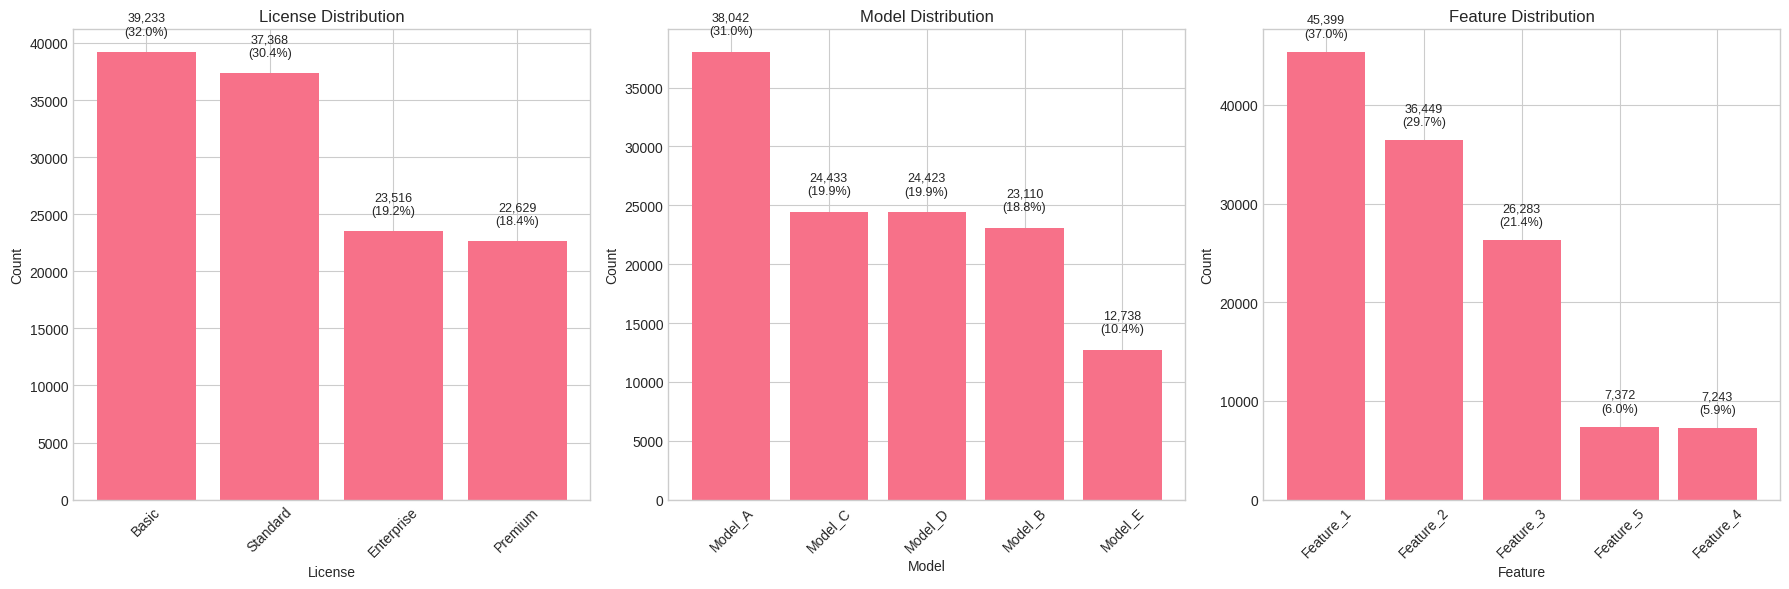

In [6]:
# Categorical variables analysis with visualizations
print("CATEGORICAL VARIABLES ANALYSIS")
print("=" * 50)

# Create visualizations for categorical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

categorical_cols = ['license', 'model', 'feature']

for i, col in enumerate(categorical_cols):
    # Get value counts
    value_counts = df[col].value_counts()
    
    # Create bar plot
    ax = axes[i]
    bars = ax.bar(value_counts.index, value_counts.values)
    ax.set_title(f'{col.title()} Distribution')
    ax.set_xlabel(col.title())
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, count in zip(bars, value_counts.values):
        percentage = (count / len(df)) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.01, 
                f'{count:,}\n({percentage:.1f}%)', 
                ha='center', va='bottom', fontsize=9)
    
    # Print summary
    print(f"\n{col.upper()}:")
    print(f"  Unique values: {len(value_counts)}")
    for val, count in value_counts.items():
        percentage = (count / len(df)) * 100
        print(f"    {val}: {count:,} ({percentage:.1f}%)")

plt.tight_layout()
plt.show()

In [7]:
# Data quality assessment
print("DATA QUALITY ASSESSMENT")
print("=" * 50)

# Check for missing values
print("\nMissing Values:")
missing_values = df.isnull().sum()
for col, missing in missing_values.items():
    percentage = (missing / len(df)) * 100
    print(f"  {col}: {missing} ({percentage:.2f}%)")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Check data types
print(f"\nData Types:")
for col, dtype in df.dtypes.items():
    print(f"  {col}: {dtype}")

# Examine user count
unique_users = df['uuid'].nunique()
total_records = len(df)
avg_records_per_user = total_records / unique_users
print(f"\nUser Analysis:")
print(f"  Unique users: {unique_users:,}")
print(f"  Total records: {total_records:,}")
print(f"  Average records per user: {avg_records_per_user:.1f}")

DATA QUALITY ASSESSMENT

Missing Values:
  uuid: 0 (0.00%)
  day_id: 0 (0.00%)
  license: 0 (0.00%)
  model: 0 (0.00%)
  feature: 0 (0.00%)
  requests_cnt: 0 (0.00%)
  spent_amount: 0 (0.00%)
  year: 0 (0.00%)
  month: 0 (0.00%)
  month_name: 0 (0.00%)
  day_of_week: 0 (0.00%)
  week_number: 0 (0.00%)
  cost_per_request: 0 (0.00%)

Duplicate rows: 0

Data Types:
  uuid: object
  day_id: datetime64[ns]
  license: object
  model: object
  feature: object
  requests_cnt: int64
  spent_amount: float64
  year: int32
  month: int32
  month_name: object
  day_of_week: object
  week_number: UInt32
  cost_per_request: float64

User Analysis:
  Unique users: 1,866
  Total records: 122,746
  Average records per user: 65.8


In [8]:
# Analyze date range and time period coverage
print("TIME PERIOD ANALYSIS")
print("=" * 50)

# Basic time analysis (day_id already converted to datetime in preprocessing)
start_date = df['day_id'].min()
end_date = df['day_id'].max()
total_days = (end_date - start_date).days + 1

print(f"\nTime Range:")
print(f"  Start date: {start_date.strftime('%Y-%m-%d')}")
print(f"  End date: {end_date.strftime('%Y-%m-%d')}")
print(f"  Total days: {total_days}")

# Check for date gaps
unique_dates = df['day_id'].nunique()
print(f"  Unique dates in data: {unique_dates}")
print(f"  Coverage: {(unique_dates/total_days)*100:.1f}%")

# Monthly breakdown using the new month_name feature
monthly_records = df['month_name'].value_counts().reindex(['March', 'April', 'May'])
print(f"\nMonthly Record Distribution:")
for month, count in monthly_records.items():
    percentage = (count / len(df)) * 100
    print(f"  {month}: {count:,} records ({percentage:.1f}%)")

TIME PERIOD ANALYSIS

Time Range:
  Start date: 2025-03-01
  End date: 2025-05-31
  Total days: 92
  Unique dates in data: 92
  Coverage: 100.0%

Monthly Record Distribution:
  March: 37,793 records (30.8%)
  April: 38,590 records (31.4%)
  May: 46,363 records (37.8%)


<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### Analysis of Section 3: Key Takeaways

The initial data assessment confirms three critical business points:

1.  **Perfect Data Integrity:** The dataset is **100% complete**, with **0 missing values** and **0 duplicate rows**. This gives us high confidence in the accuracy of our $1.5M revenue analysis.
    * [cite_start]*(Это твой вывод из ячейки `In [7]` [cite: 322-333])*

2.  **Clear Product Hierarchy:** The product mix is not random. **`Feature_1`** (37.0% of all records) and **`Model_A`** (31.0%) are clear market leaders. Conversely, **`Feature_4`** (5.9%) and **`Feature_5`** (6.0%) are niche products, presenting a potential area for a growth investigation.
    * [cite_start]*(Это твой вывод из графиков ячейки `In [6]` [cite: 251, 256, 263-265])*

3.  **Strong Growth Signal:** The data covers the 92-day period without any gaps. Crucially, the volume of activity records grew steadily, from **37,793** in March to **46,363** in May—a strong preliminary indicator of business growth.
    * [cite_start]*(Это твой вывод из ячейки `In [8]` [cite: 386, 388])*

With our data validated, we can now move to the core of the analysis: user behavior.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

## 4. User Behavior Analysis
This is the core of the analysis. We know from our initial review that "average" users are misleading. Now, we will investigate the relationship between user activity (`requests_cnt`) and spending (`spent_amount`) to find the true value drivers.

This section will follow a logical path:
1.  **Analyze Cost Structure:** We'll start by examining the cost of individual requests to see if there is a pattern.
2.  **Identify Product Groups:** We'll see if this cost pattern maps to specific models, creating distinct product tiers.
3.  **Prove the Hypothesis:** Finally, we will use a correlation plot to prove that these two product tiers create two different, predictable patterns of user spending.

In [9]:
# User activity distribution analysis
print("USER ACTIVITY DISTRIBUTION")
print("=" * 50)

# User activity segments
print("\nUser Activity Summary:")
print(f"  Total users: {len(user_stats):,}")
print(f"  Average requests per user: {user_stats['total_requests'].mean():.1f}")
print(f"  Average spending per user: ${user_stats['total_spent'].mean():.2f}")
print(f"  Average active days per user: {user_stats['active_days'].mean():.1f}")

# Activity level segments
activity_segments = user_stats['activity_level'].value_counts()

print(f"\nUser Activity Segments:")
for segment, count in activity_segments.items():
    percentage = (count / len(user_stats)) * 100
    avg_requests = user_stats[user_stats['activity_level'] == segment]['total_requests'].mean()
    total_spent = user_stats[user_stats['activity_level'] == segment]['total_spent'].sum()
    avg_spent = user_stats[user_stats['activity_level'] == segment]['total_spent'].mean()
    print(f"  {segment}: {count:,} users ({percentage:.1f}%) - Avg requests: {avg_requests:.1f}, Total spend: ${total_spent:.2f} Avg spend: ${avg_spent:.2f}")

USER ACTIVITY DISTRIBUTION

User Activity Summary:
  Total users: 1,866
  Average requests per user: 3371.9
  Average spending per user: $804.35
  Average active days per user: 65.8

User Activity Segments:
  High Activity: 1,187 users (63.6%) - Avg requests: 3658.7, Total spend: $1070392.26 Avg spend: $901.76
  Medium Activity: 416 users (22.3%) - Avg requests: 442.4, Total spend: $55101.87 Avg spend: $132.46
  Low Activity: 148 users (7.9%) - Avg requests: 57.1, Total spend: $2636.79 Avg spend: $17.82
  Very High Activity: 87 users (4.7%) - Avg requests: 20187.2, Total spend: $372646.56 Avg spend: $4283.29
  Minimal Activity: 28 users (1.5%) - Avg requests: 12.9, Total spend: $135.86 Avg spend: $4.85


In [10]:
# Requests vs Spending relationship analysis
print("REQUESTS vs SPENDING CORRELATION ANALYSIS")
print("=" * 50)

# Calculate correlation between requests and spending
correlation = df['requests_cnt'].corr(df['spent_amount'])
print(f"\nOverall correlation between requests and spending: {correlation:.3f}")

# Cost per request analysis (already created in preprocessing)
avg_cost_per_request = df['cost_per_request'].mean()
print(f"Average cost per request: ${avg_cost_per_request:.3f}")

# Cost efficiency by different dimensions
print(f"\nCost per request by License Type:")
license_cost = df.groupby('license')['cost_per_request'].mean().sort_values(ascending=False)
for license_type, cost in license_cost.items():
    print(f"  {license_type}: ${cost:.3f}")

print(f"\nCost per request by Model:")
model_cost = df.groupby('model')['cost_per_request'].mean().sort_values(ascending=False)
for model, cost in model_cost.items():
    print(f"  {model}: ${cost:.3f}")

print(f"\nCost per request by Feature:")
feature_cost = df.groupby('feature')['cost_per_request'].mean().sort_values(ascending=False)
for feature, cost in feature_cost.items():
    print(f"  {feature}: ${cost:.3f}")

REQUESTS vs SPENDING CORRELATION ANALYSIS

Overall correlation between requests and spending: 0.944
Average cost per request: $0.279

Cost per request by License Type:
  Standard: $0.282
  Basic: $0.279
  Enterprise: $0.277
  Premium: $0.276

Cost per request by Model:
  Model_A: $0.369
  Model_B: $0.366
  Model_D: $0.192
  Model_E: $0.190
  Model_C: $0.190

Cost per request by Feature:
  Feature_3: $0.283
  Feature_5: $0.282
  Feature_2: $0.280
  Feature_4: $0.277
  Feature_1: $0.276


Analyzing the cost distribution...
Cost per request visualization limited to: $0.540


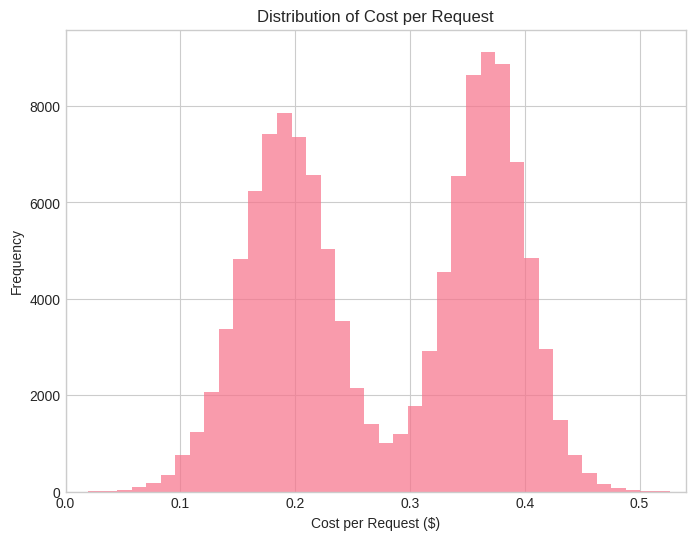

In [11]:
# 4.1. Clue A: The "Two-Peak" Economy
print("Analyzing the cost distribution...")

# Plotting ax7 (Distribution of Cost per Request)
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate 95th percentile
cost_95th = df['cost_per_request'].quantile(0.95)
plot_limit = min(cost_95th * 1.5, df['cost_per_request'].quantile(0.99) + 0.1)

df['cost_per_request'].hist(bins=50, alpha=0.7, ax=ax)
ax.set_title('Distribution of Cost per Request')
ax.set_xlabel('Cost per Request ($)')
ax.set_ylabel('Frequency')
ax.set_xlim(0, plot_limit)

print(f"Cost per request visualization limited to: ${plot_limit:.3f}")
plt.show()

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### Insight 4.1: The "Two-Peak" Economy

The analysis of user behavior begins with this single chart, and it's revealing.

The `Distribution of Cost per Request` is not a standard bell curve. It is a **bimodal distribution** with two clear, distinct peaks:
1.  A large peak around **$0.19**
2.  A second, significant peak around **$0.37**

This is our first clue: Users are not paying an "average" price. They are actively clustered in two different pricing economies. **Why?**

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

Analyzing cost by model...


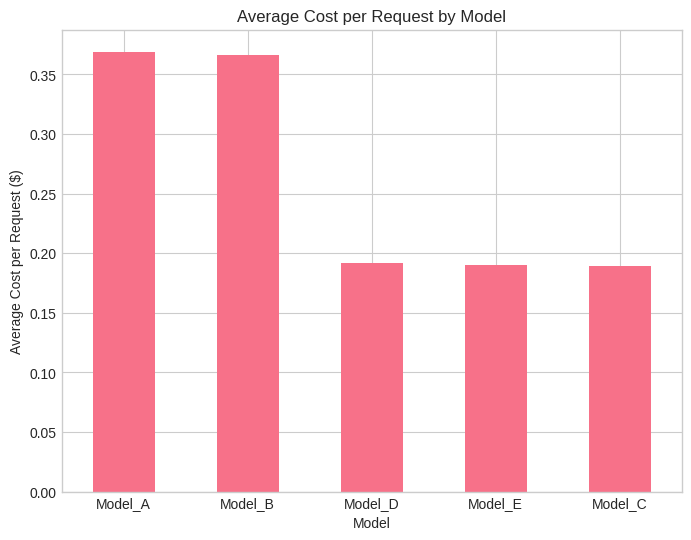

In [12]:
# 4.2. Clue B: The Model Tiers
print("Analyzing cost by model...")

# Plotting ax5 (Average Cost per Request by Model)
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate model_cost
model_cost = df.groupby('model')['cost_per_request'].mean().sort_values(ascending=False)

model_cost.plot(kind='bar', ax=ax)
ax.set_title('Average Cost per Request by Model')
ax.set_xlabel('Model')
ax.set_ylabel('Average Cost per Request ($)')
ax.tick_params(axis='x', rotation=0)

plt.show()

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### Insight 4.2: The "Premium" and "Economy" Tiers

This chart provides the answer. The two peaks from our first clue map perfectly to two distinct model tiers:

* **Premium Tier (A, B):** Both `Model_A` ($0.369) and `Model_B` ($0.366) cluster around the **$0.37** peak.
* **Economy Tier (C, D, E):** `Model_C`, `Model_D`, and `Model_E` all cluster around the **$0.19** peak.

This confirms our hypothesis: `Model` is the primary driver of cost. We don't have five models; we have two *tiers* of models.

**The next logical question is:** How does this two-tiered economy affect user spending?

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

Plotting the final correlation insight (1x2 layout) using user's exact code...


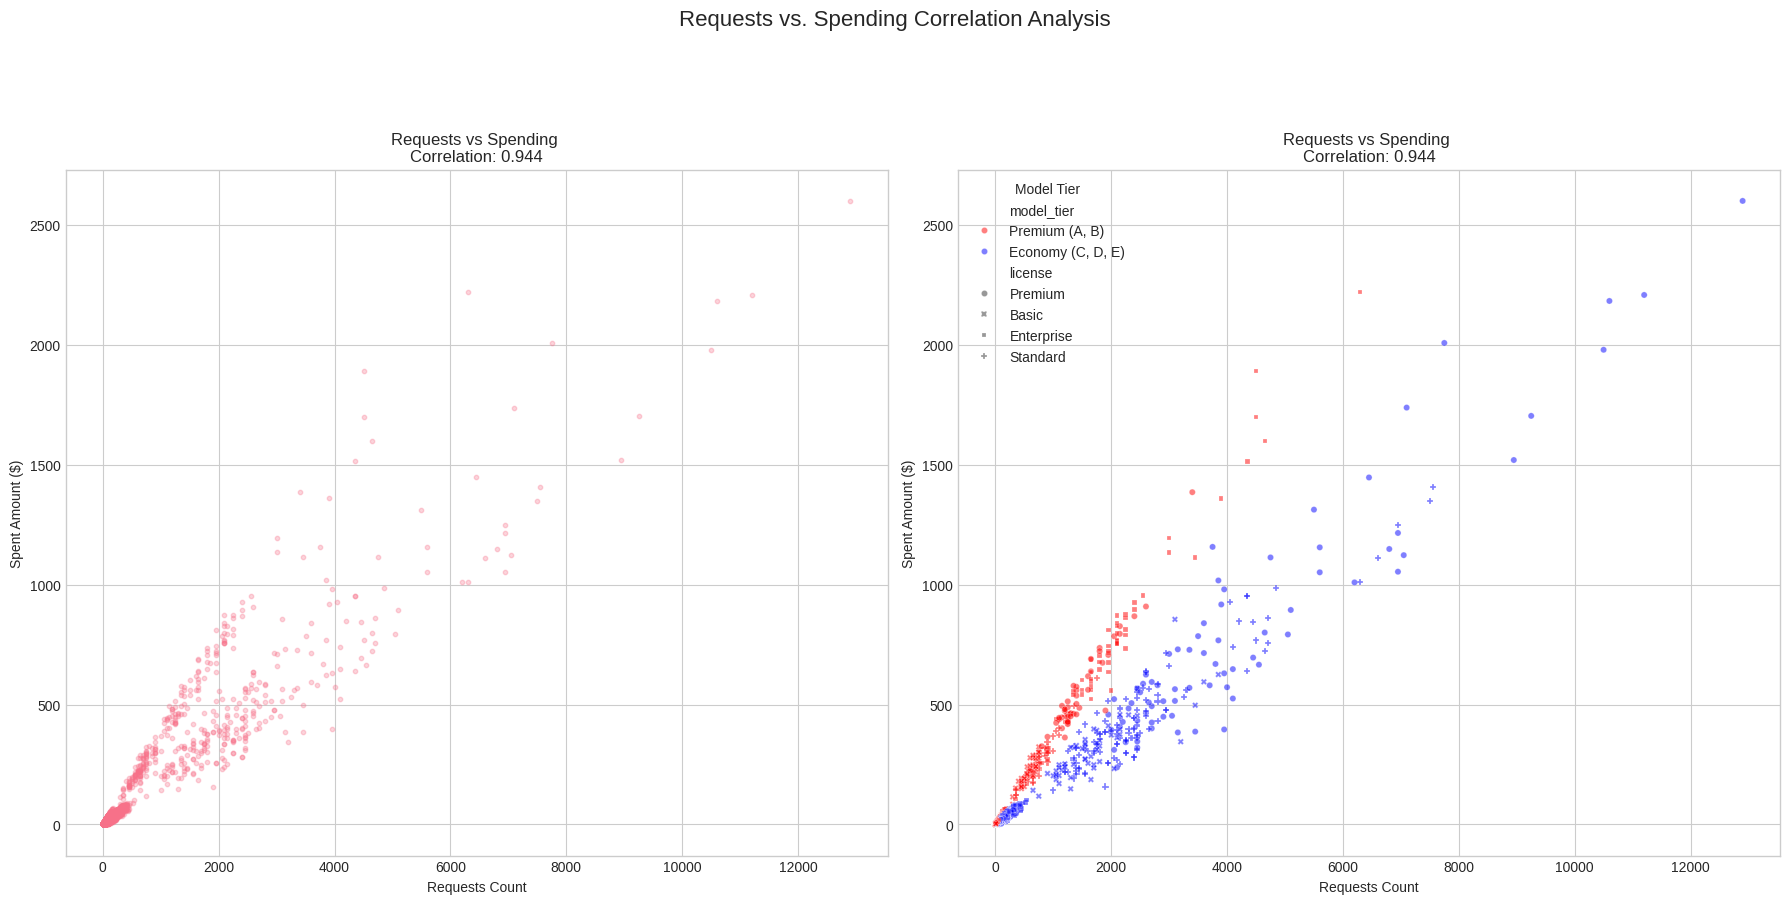

In [13]:
# 4.3. Requests vs Spending \nCorrelation
print("Plotting the final correlation insight (1x2 layout) using user's exact code...")

correlation = df['requests_cnt'].corr(df['spent_amount'])

# Split models in two types
economy_models = ['Model_C', 'Model_D', 'Model_E']
df['model_tier'] = df['model'].apply(
    lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)'
)

# Plotting (1x2 layout)
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle('Requests vs. Spending Correlation Analysis', fontsize=16, y=1.03)


# Plot 1
ax8 = axes[0]
ax8.scatter(df['requests_cnt'], df['spent_amount'], alpha=0.3, s=10)
ax8.set_title(f'Requests vs Spending \nCorrelation: {correlation:.3f}')
ax8.set_xlabel('Requests Count')
ax8.set_ylabel('Spent Amount ($)')


# Plot 2
ax9 = axes[1] 
sns.scatterplot(
    data=df,
    x='requests_cnt',
    y='spent_amount',
    hue='model_tier',
    style='license',
    palette={'Economy (C, D, E)': 'blue', 'Premium (A, B)': 'red'},
    alpha=0.5,
    s=20,
    ax=ax9
)
ax9.set_title(f'Requests vs Spending \nCorrelation: {correlation:.3f}')
ax9.set_xlabel('Requests Count')
ax9.set_ylabel('Spent Amount ($)')
ax9.legend(title='Model Tier')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### Insight 4.3: Correlation Analysis by Model Tier

This side-by-side comparison validates the findings from sections 4.1 and 4.2.

* **Plot A (Overall Correlation):** This plot shows a strong positive correlation (0.944) between `requests_cnt` and `spent_amount`. However, the data points form a wide cloud, suggesting that a single linear model does not fully describe the relationship.

* **Plot B (Analysis by Model Tier):** This plot reveals the underlying variable. By coloring the data points by our previously identified "Premium" and "Economy" model tiers, the cloud resolves into two distinct, linear patterns:
    1.  **Economy Tier (Blue):** This line demonstrates a **"Volume"**-based cost structure. It has a lower slope, indicating that spending increases are primarily driven by a high volume of low-cost requests.
    2.  **Premium Tier (Red):** This line demonstrates a **"Value"**-based cost structure. The slope is significantly steeper, indicating that spending increases rapidly with fewer, high-cost requests.

**Conclusion:** The analysis confirms that `Model` choice is the primary driver segmenting user spending behavior. The next step is to analyze *which* user segments (e.g., by license) align with which spending pattern.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

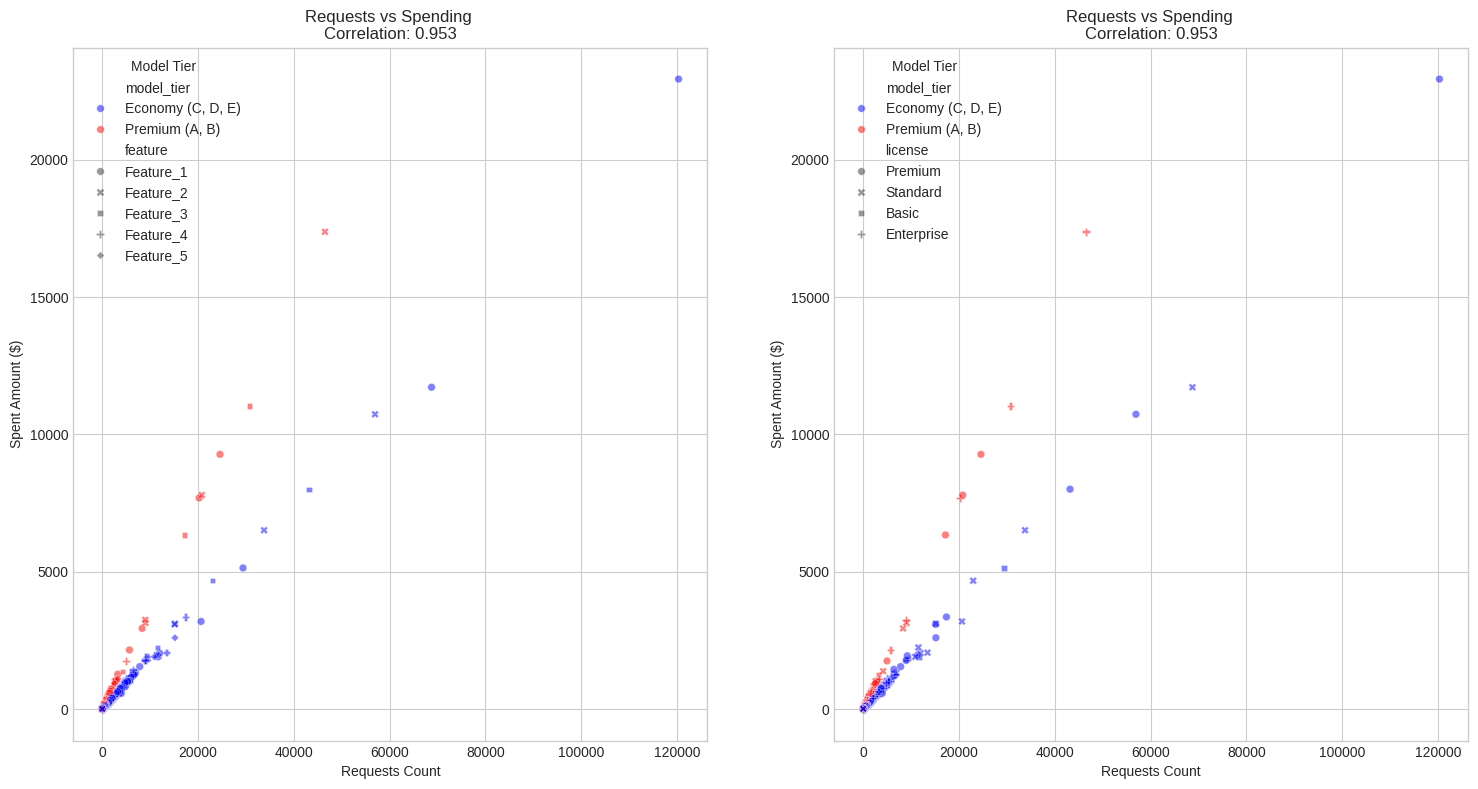

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

ax = axes[0]
economy_models = ['Model_C', 'Model_D', 'Model_E']
nodate_df['model_tier'] = nodate_df['model'].apply(
    lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)'
)
correlation = nodate_df['total_requests'].corr(nodate_df['total_spent'])
sns.scatterplot(
    data=nodate_df,
    x='total_requests',
    y='total_spent',
    hue='model_tier',
    style='feature',
    palette={'Economy (C, D, E)': 'blue', 'Premium (A, B)': 'red'},
    alpha=0.5,
    s=30,
    ax=ax
)
ax.set_title(f'Requests vs Spending \nCorrelation: {correlation:.3f}')
ax.set_xlabel('Requests Count')
ax.set_ylabel('Spent Amount ($)')
ax.legend(title='Model Tier')

ax = axes[1]
economy_models = ['Model_C', 'Model_D', 'Model_E']
nodate_df['model_tier'] = nodate_df['model'].apply(
    lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)'
)
correlation = nodate_df['total_requests'].corr(nodate_df['total_spent'])
sns.scatterplot(
    data=nodate_df,
    x='total_requests',
    y='total_spent',
    hue='model_tier',
    style='license',
    palette={'Economy (C, D, E)': 'blue', 'Premium (A, B)': 'red'},
    alpha=0.5,
    s=30,
    ax=ax
)
ax.set_title(f'Requests vs Spending \nCorrelation: {correlation:.3f}')
ax.set_xlabel('Requests Count')
ax.set_ylabel('Spent Amount ($)')
ax.legend(title='Model Tier')


### 4.4. Analysis of Aggregated Data (A Final Hypothesis)

This aggregated view confirms our "Two Economies" hypothesis. The correlation is stronger (0.953), and the two tiers (red/blue) are clearly visible.

However, the plot on the right (styled by `license`) does not provide a final insight. Instead, it provides our **final and most critical hypothesis.**

1.  **High-Value Segments:** We can confirm that the high-value outliers belong almost exclusively to `+` (**Enterprise**) and `*` (**Premium**) licenses.

2.  **A Visual Hypothesis:** When looking at the high-request outliers (right side of the plot), the data *strongly suggests* a separation:
    * It *appears* that **Enterprise users (`+`)** are clustered in the **Red "Premium-Cost" Tier**.
    * It *appears* that **Premium users (`*`)** are clustered in the **Blue "Economy-Cost" Tier**.

**Conclusion:** This visual pattern is a supposition, not a proven fact. We have proven *what* (Two Economies) and *who* (Enterprise/Premium). Now, we must formally test the hypothesis of *how* these two segments behave differently.

## 5. Cross-Dimensional Analysis: Linking License Type to Model Strategy
In Section 4, we established that the product's pricing is divided into two tiers: "Premium-Cost" (Models A, B) and "Economy-Cost" (Models C, D, E). We also identified that high-activity users, predominantly those with Enterprise and Premium licenses, are the primary revenue drivers.

This section provides a deeper analysis of these two high-value segments to determine if their model acquisition and usage strategies differ.

In [15]:
# Custom Binning for User Activity Analysis
custom_bins = segment_distribution if segment_distribution else [0, 20, 100, 1000, 10000, np.inf]
custom_labels = [f'Minimal Activity \n < {custom_bins[1]}',
            f'Low Activity \n {custom_bins[1]}-{custom_bins[2]}',
            f'Medium Activity \n {custom_bins[2]}-{custom_bins[3]}',
            f'High Activity \n {custom_bins[3]}-{custom_bins[4]}',
            f'Very High Activity \n > {custom_bins[4]}']
user_stats['activity_bin_custom'] = pd.cut(user_stats['total_requests'], bins=custom_bins, labels=custom_labels)
spend_by_bin = user_stats.groupby('activity_bin_custom')['total_spent'].sum()
users_per_bin = user_stats.groupby('activity_bin_custom').size()
spend_by_bin_df = pd.DataFrame({
    'Total Spending ($)': spend_by_bin,
    'User Count': users_per_bin
}).reset_index()
print(" - 'spend_by_bin_df' created.")

def get_preference_data(df_in, user_stats_in, category_col, N_BINS_rest=20, CHUNK_SIZE_very_high=20):
    
    # Split users into "Rest" and "Very High Activity"
    rest_users_df = user_stats_in[user_stats_in['activity_level'] != 'Very High Activity'].copy()
    very_high_users_df = user_stats_in[user_stats_in['activity_level'] == 'Very High Activity'].copy()


    # Bin the "Body" (Rest users)
    # (Bins from 0 to N_BINS_rest-1)
    rest_users_df['activity_bin_numeric'] = pd.qcut(
        rest_users_df['total_requests'], 
        q=N_BINS_rest, 
        labels=False, 
        duplicates='drop'
    )
    
    # Bin the "Tail" (Very High Activity users)
    all_bins_series = rest_users_df['activity_bin_numeric'] # Initialize with "Rest" bins
    
    if not very_high_users_df.empty:
        # Sort "Very High" users by total_requests
        very_high_users_df = very_high_users_df.sort_values('total_requests')

        # Isolate top-1
        top_1_user_uuid = very_high_users_df.index[-1]

        # Isolate *all others* in the "tail"
        other_very_high_users = very_high_users_df.iloc[:-1]
        n_others = len(other_very_high_users)

        # Generate bins for "chunks" (starting from N_BINS_rest)
        # e.g., users 0-19 -> bin 20; users 20-39 -> bin 21
        other_bins_array = N_BINS_rest + (np.arange(n_others) // CHUNK_SIZE_very_high)
        other_bins_series = pd.Series(other_bins_array, index=other_very_high_users.index, name='activity_bin_numeric')
        
        # Determine bin for top-1 user
        if n_others > 0:
            last_bin_for_chunks = other_bins_array.max()
            top_1_bin = last_bin_for_chunks + 1
        else:
            top_1_bin = N_BINS_rest
            
        top_1_bin_series = pd.Series([top_1_bin], index=[top_1_user_uuid], name='activity_bin_numeric')

        # Combine all bins ("Body" + "Chunks" + "Top-1")
        all_bins_series = pd.concat([rest_users_df['activity_bin_numeric'], other_bins_series, top_1_bin_series])
        
    
    # Map bins back to the main dataframe
    df_in['activity_bin_numeric'] = df_in['uuid'].map(all_bins_series)
    df_in['activity_bin_numeric'] = df_in['activity_bin_numeric'].fillna(0).astype(int)

    # Calculate average requests per bin
    user_stats_with_bins = user_stats_in.join(all_bins_series)
    bin_request_map = user_stats_with_bins.groupby('activity_bin_numeric')['total_requests'].mean().round(0)

    # Calculate preference data
    grouped_df = df_in.groupby(['activity_bin_numeric', category_col])['requests_cnt'].sum().to_frame()
    bin_totals = grouped_df.groupby(level='activity_bin_numeric')['requests_cnt'].transform('sum')
    grouped_df['percentage'] = (grouped_df['requests_cnt'] / bin_totals).fillna(0)
    normalized_data = grouped_df.reset_index()
    normalized_data['activity_mean_requests'] = normalized_data['activity_bin_numeric'].map(bin_request_map)
    
    return normalized_data


# Run the calculation for 'model' and 'license'
norm_data_model = get_preference_data(df.copy(), user_stats.copy(), 'model')
print(" - 'norm_data_model' created.")
norm_data_feature = get_preference_data(df.copy(), user_stats.copy(), 'feature')
print(" - 'norm_data_feature' created.")
norm_data_license = get_preference_data(df.copy(), user_stats.copy(), 'license')
print(" - 'norm_data_license' created.")

 - 'spend_by_bin_df' created.
 - 'norm_data_model' created.
 - 'norm_data_feature' created.
 - 'norm_data_license' created.


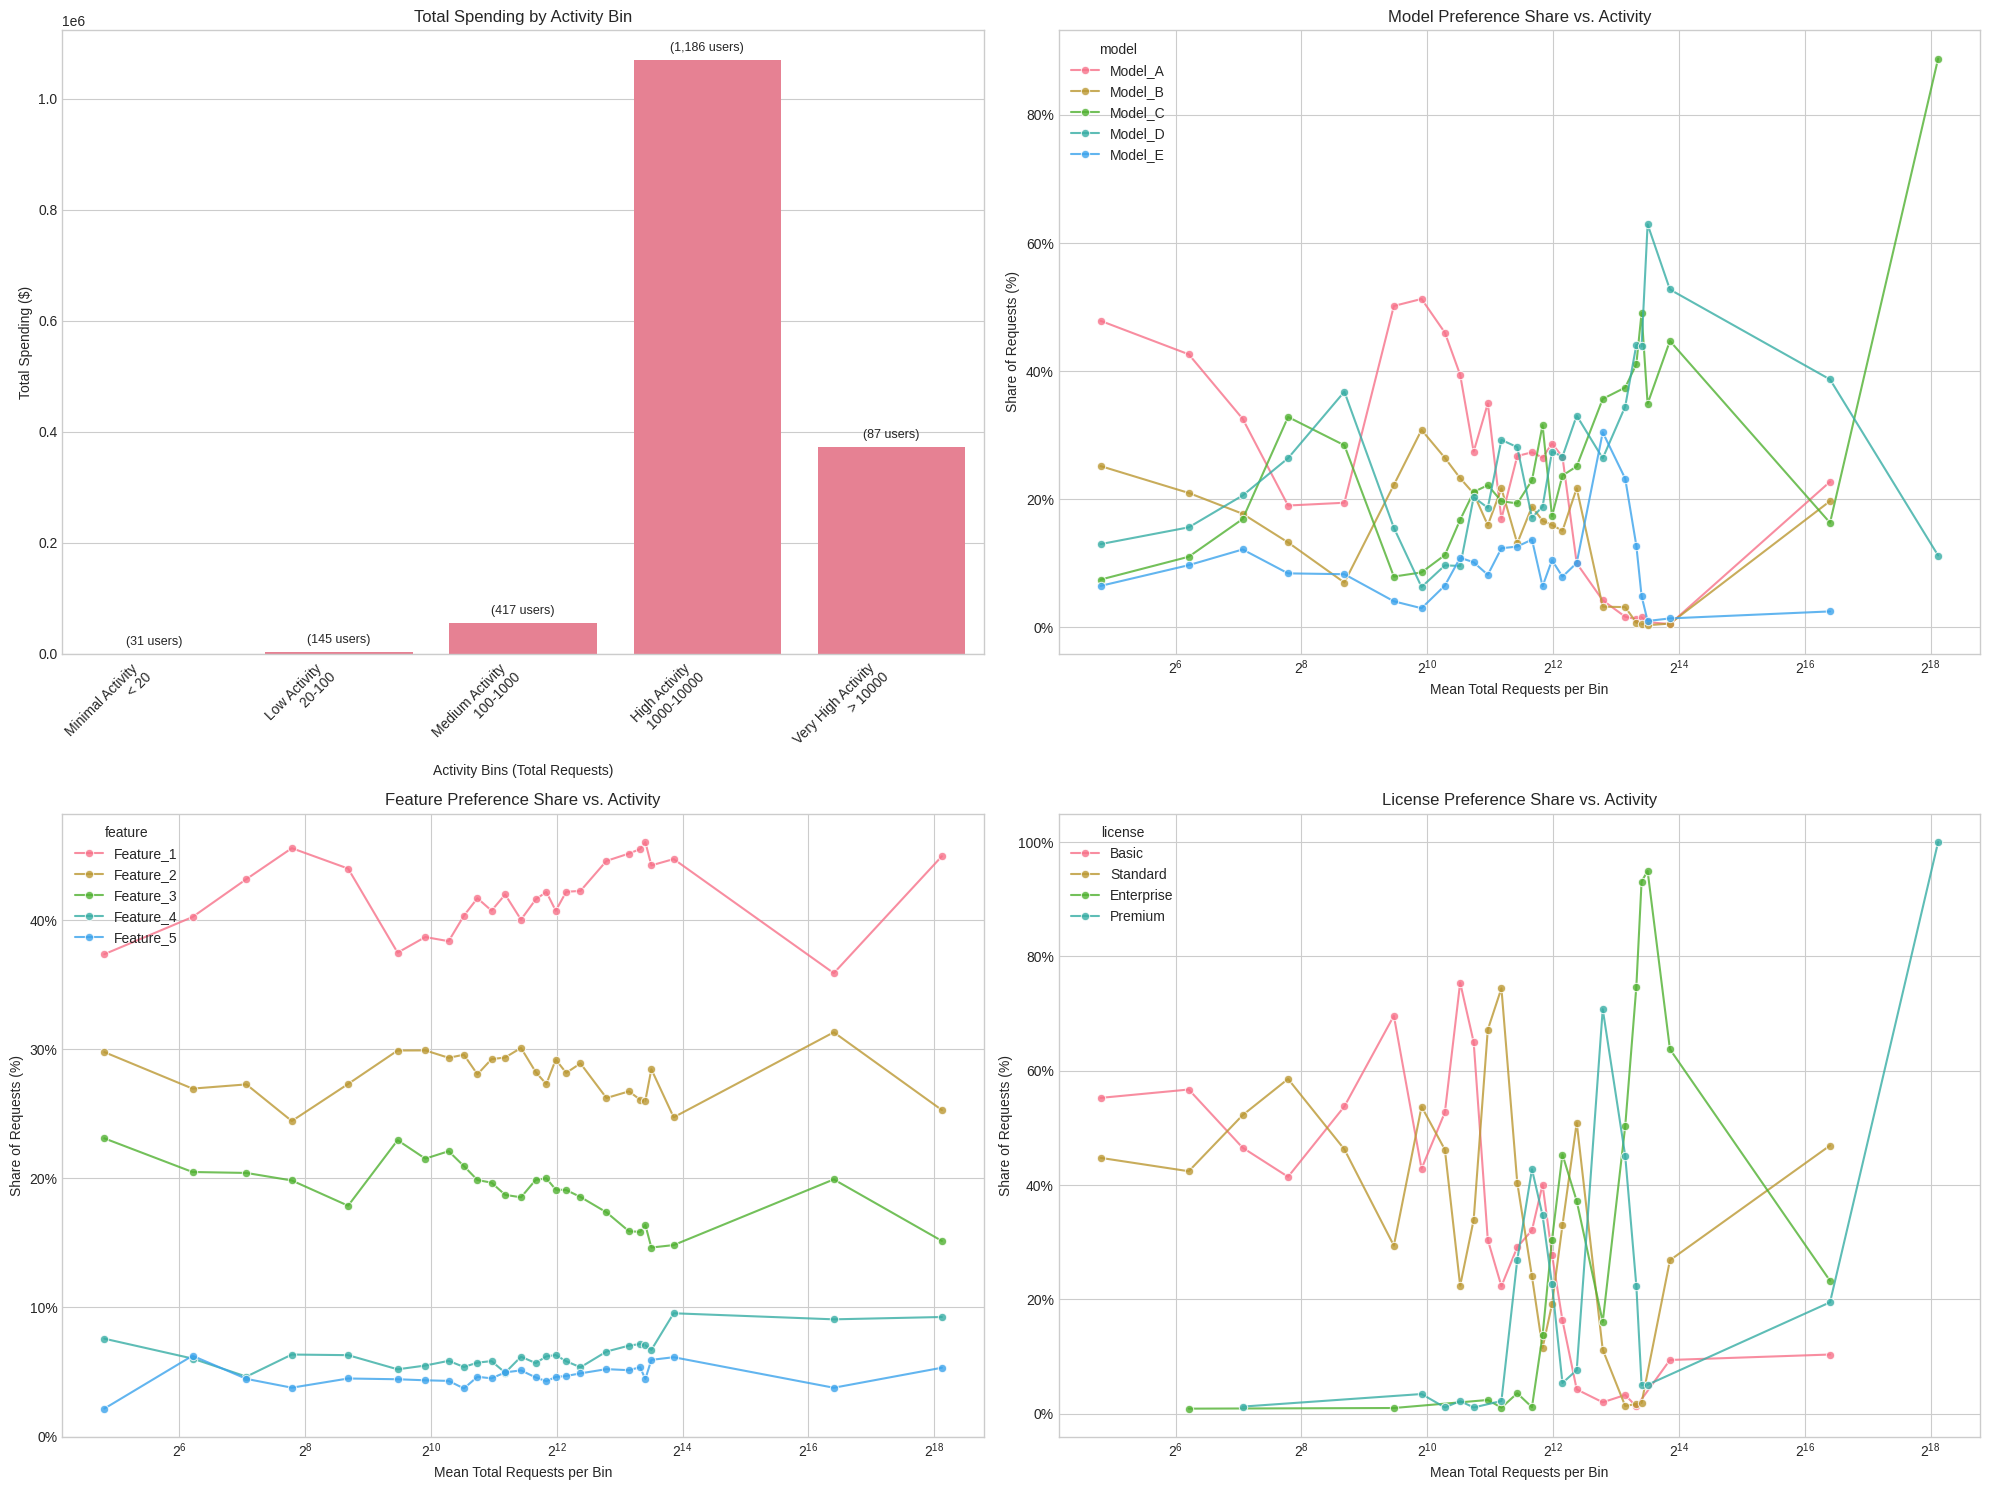

In [16]:
# Create visualizations for activity and preferences
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Spending Distribution by Activity (Custom Bins)
ax_00 = axes[0, 0]
sns.barplot(
    data=spend_by_bin_df, 
    x='activity_bin_custom', y='Total Spending ($)',
    ax=ax_00, color=sns.color_palette("husl", 1)[0]
)
ax_00.set_title('Total Spending by Activity Bin')
ax_00.set_xlabel('Activity Bins (Total Requests)')
ax_00.set_ylabel('Total Spending ($)')
ax_00.set_xticklabels(ax_00.get_xticklabels(), rotation=45, ha='right')

for bar, count in zip(ax_00.patches, spend_by_bin_df['User Count']):
    bar_height = bar.get_height() + (spend_by_bin_df['Total Spending ($)'].max() * 0.01)
    label_text = f"({count:,.0f} users)"
    ax_00.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=bar_height,     
        s=label_text,
        ha='center',
        va='bottom',
        fontsize=9
    )

# Model Preference Shift
ax_01 = axes[0, 1]
sns.lineplot(
    data=norm_data_model, 
    x='activity_mean_requests', y='percentage',
    hue='model', marker='o', alpha=0.8, ax=ax_01
)
ax_01.set_title('Model Preference Share vs. Activity')
ax_01.set_xlabel('Mean Total Requests per Bin')
ax_01.set_ylabel('Share of Requests (%)')
ax_01.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax_01.set_xscale('log', base=2)

# Feature Preference Shift
ax_10 = axes[1, 0]
sns.lineplot(
    data=norm_data_feature, 
    x='activity_mean_requests', y='percentage',
    hue='feature', marker='o', alpha=0.8, ax=ax_10
)
ax_10.set_title('Feature Preference Share vs. Activity')
ax_10.set_xlabel('Mean Total Requests per Bin')
ax_10.set_ylabel('Share of Requests (%)')
ax_10.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax_10.set_xscale('log', base=2)

# License Preference Shift
ax_11 = axes[1, 1]
sns.lineplot(
    data=norm_data_license, 
    x='activity_mean_requests', y='percentage',
    hue='license', marker='o', alpha=0.8, ax=ax_11
)
ax_11.set_title('License Preference Share vs. Activity')
ax_11.set_xlabel('Mean Total Requests per Bin')
ax_11.set_ylabel('Share of Requests (%)')
ax_11.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax_11.set_xscale('log', base=2)

# Final Touches
plt.tight_layout()
plt.show()

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 5.1. Analysis by Activity Segment: Identifying Key Segments and Their Preferences

The charts above are used to identify the most valuable user groups and reveal their underlying preferences.

1.  **Source of Revenue ("Total Spending" Chart)**
    The "Total Spending by Activity Bin" chart (top-left) clearly shows that the vast majority of revenue is generated by the **"High Activity"** and **"Very High Activity"** segments. The "High Activity" segment is also the larger of these two groups. This confirms the need to focus our analysis on these specific segments.

2.  **Preference Analysis (Remaining 3 Charts)**
    * **Features (Bottom-Left):** Feature preferences are **stable** across all segments. This is not a key differentiator for high-activity users.
    * **Licenses and Models (Right):** These charts show a **similar and strong dynamic**. As user activity increases (moving into "High Activity"), the share of **Enterprise** and **Premium** licenses rises sharply. Simultaneously, the usage share of the economy **Models C and D** also increases.

3.  **Key Question and Next Steps**
    We observe a correlation: the growth in the share of the most valuable licenses (Enterprise/Premium) coincides with the growth in the share of the cheapest models (C/D).

    However, these line charts only show an aggregated trend and are too "noisy" to separate user behaviors. We cannot answer the question: are Enterprise and Premium users the ones switching to cheaper models, or are these two different but simultaneous trends?

    To get a precise answer, we must examine the model preferences *within* the **Enterprise** and **Premium** segments in detail.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 5.2. Pareto Analysis: Quantifying Revenue Concentration

Before analyzing the *behaviors* of our high-value segments, we must first confirm their *financial contribution*. This Pareto analysis tests the classic 80/20 rule to understand exactly where our revenue comes from and validate our focus on the Enterprise and Premium segments.

In [17]:
user_license_map = df.groupby('uuid')['license'].agg(
    lambda x: x.mode()[0] if not x.empty else 'Unknown'
).reset_index()

user_stats_with_license = user_stats.merge(user_license_map, on='uuid')

pareto_df = user_stats_with_license.sort_values(by='total_spent', ascending=False)

total_spent_all = pareto_df['total_spent'].sum()
total_requests_all = pareto_df['total_requests'].sum()
n_users = len(pareto_df)

pareto_df['cum_spent_pct'] = 100 * pareto_df['total_spent'].cumsum() / total_spent_all
pareto_df['cum_requests_pct'] = 100 * pareto_df['total_requests'].cumsum() / total_requests_all

idx_1_pct = int(n_users * 0.01)
idx_5_pct = int(n_users * 0.05)
idx_20_pct = int(n_users * 0.20)

cut_1_pct = pareto_df.iloc[idx_1_pct - 1]
cut_5_pct = pareto_df.iloc[idx_5_pct - 1]
cut_20_pct = pareto_df.iloc[idx_20_pct - 1]

def get_dominant_licenses(df_slice):
    return ", ".join(df_slice['license'].value_counts().index[:2].tolist())

lic_top_1 = get_dominant_licenses(pareto_df.iloc[:idx_1_pct])
lic_top_5 = get_dominant_licenses(pareto_df.iloc[:idx_5_pct])
lic_top_20 = get_dominant_licenses(pareto_df.iloc[:idx_20_pct])
lic_bottom_80 = get_dominant_licenses(pareto_df.iloc[idx_20_pct:])

data = {
    'Segment': ['Top 1%', 'Top 5%', 'Top 20%', 'Bottom 80%'],
    'User %': ['1%', '5%', '20%', '80%'],
    'Total Revenue %': [
        cut_1_pct['cum_spent_pct'],
        cut_5_pct['cum_spent_pct'],
        cut_20_pct['cum_spent_pct'],
        100.0 - cut_20_pct['cum_spent_pct']
    ],
    'Total Requests %': [
        cut_1_pct['cum_requests_pct'],
        cut_5_pct['cum_requests_pct'],
        cut_20_pct['cum_requests_pct'],
        100.0 - cut_20_pct['cum_requests_pct']
    ],
    'Dominant Licenses': [lic_top_1, lic_top_5, lic_top_20, lic_bottom_80]
}

final_pareto_table = pd.DataFrame(data).set_index('Segment')

final_pareto_table['Total Revenue %'] = final_pareto_table['Total Revenue %'].map('{:.1f}%'.format)
final_pareto_table['Total Requests %'] = final_pareto_table['Total Requests %'].map('{:.1f}%'.format)

print("--- Value Table 4: Pareto Analysis (Revenue Distribution) ---")
print(final_pareto_table)

--- Value Table 4: Pareto Analysis (Revenue Distribution) ---
           User % Total Revenue % Total Requests %     Dominant Licenses
Segment                                                                 
Top 1%         1%           15.0%            15.4%  Standard, Enterprise
Top 5%         5%           25.9%            28.4%   Enterprise, Premium
Top 20%       20%           55.6%            57.9%   Enterprise, Premium
Bottom 80%    80%           44.4%            42.1%       Basic, Standard


<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 5.3. Insight: The "Hybrid" Revenue Model (80/20 Rule Rejected)

The Pareto analysis **rejects the 80/20 rule**. Our business is not driven by a few "whales" (the Top 1% account for only 15.0% of revenue).

Instead, the data reveals a healthy, **hybrid revenue model** built on two pillars:

1.  **The Concentrated Core (Top 20%):** Dominated by **Enterprise & Premium**, this segment drives the majority of revenue (**55.6%**). This validates a focused, Sales-Led strategy.
2.  **The High-Value Long Tail (Bottom 80%):** Dominated by **Basic & Standard**, this segment provides a critical **44.4%** of revenue, proving the success of our Product-Led Growth (PLG) funnel.

**Next Step:** Since the Top 20% (Enterprise/Premium) are both the most valuable and behave differently, our analysis must now focus on dissecting their specific behavioral strategies.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">



MODEL PREFERENCES BY ACTIVITY LEVEL
----------------------------------------

Minimal Activity Users (28 users):
  Total requests: 361
  Model_A: 64.0%
  Model_B: 36.0%

Low Activity Users (148 users):
  Total requests: 8,451
  Model_A: 44.3%
  Model_B: 22.1%
  Model_D: 15.9%
  Model_E: 8.9%
  Model_C: 8.8%

Medium Activity Users (416 users):
  Total requests: 184,021
  Model_A: 39.8%
  Model_B: 21.0%
  Model_D: 18.4%
  Model_C: 14.9%
  Model_E: 5.9%

High Activity Users (1187 users):
  Total requests: 4,342,932
  Model_C: 27.0%
  Model_D: 26.2%
  Model_A: 18.1%
  Model_E: 15.3%
  Model_B: 13.4%

Very High Activity Users (87 users):
  Total requests: 1,756,286
  Model_C: 42.3%
  Model_D: 41.1%
  Model_A: 7.3%
  Model_B: 6.1%
  Model_E: 3.2%


FEATURE PREFERENCES BY ACTIVITY LEVEL
----------------------------------------

Minimal Activity Users (28 users):
  Total requests: 361
  Feature_1: 42.1%
  Feature_3: 28.8%
  Feature_2: 27.1%
  Feature_4: 1.9%

Low Activity Users (148 users):


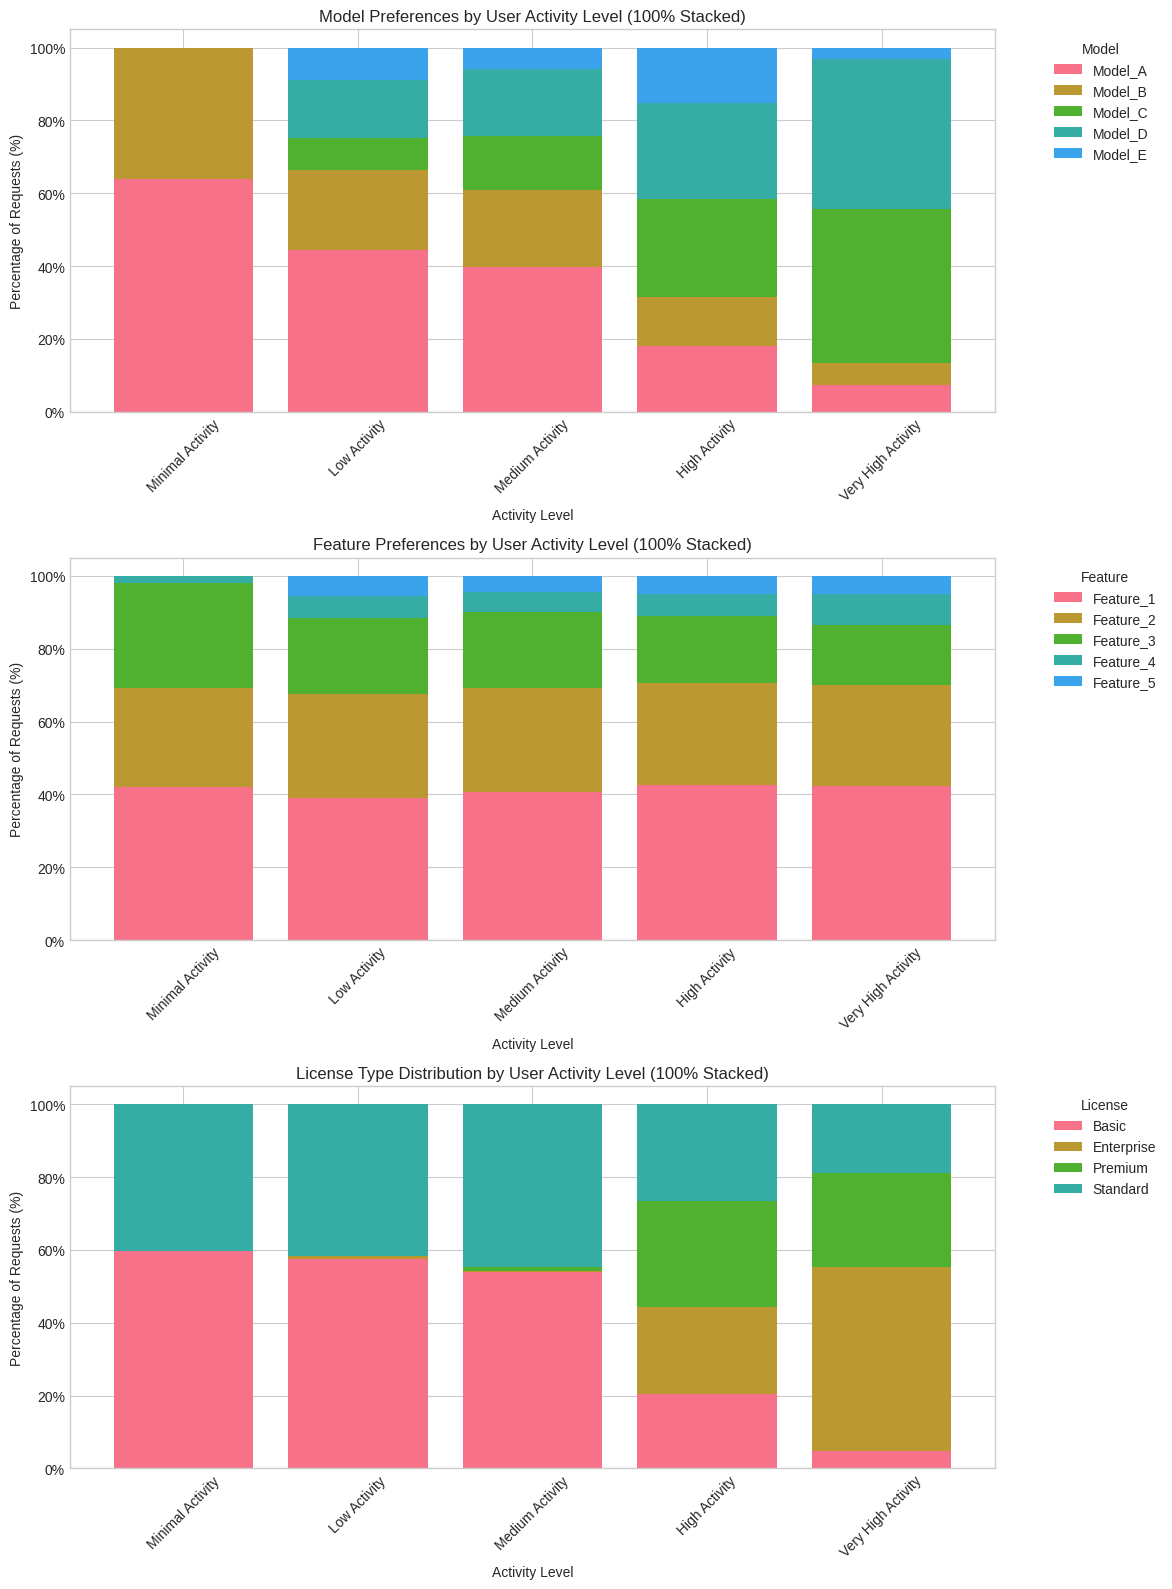


KEY INSIGHTS

Activity Level Summary:
  Minimal Activity: 28 users, 13 avg requests, $4.85 avg revenue
  Low Activity: 148 users, 57 avg requests, $17.82 avg revenue
  Medium Activity: 416 users, 442 avg requests, $132.46 avg revenue
  High Activity: 1187 users, 3659 avg requests, $901.76 avg revenue
  Very High Activity: 87 users, 20187 avg requests, $4283.29 avg revenue


In [18]:
# Create comprehensive user dataset with activity levels and preferences
# We merge 'activity_level' from user_stats into the main df based on 'uuid'
# This links every *request* (from df) to its user's *activity segment*
user_activity_analysis = df.merge(user_stats[['activity_level']], left_on='uuid', right_index=True)

# Define activity groups for analysis (in logical order)
activity_groups = ['Minimal Activity', 'Low Activity', 'Medium Activity', 'High Activity', 'Very High Activity']

# Function to analyze preferences by activity level
def analyze_preferences_by_activity(category_col, title):
    print(f"\n{title} PREFERENCES BY ACTIVITY LEVEL")
    print("-" * 40)
    
    # Calculate preferences for each activity level
    preference_data = []
    
    for activity in activity_groups:
        if activity in user_activity_analysis['activity_level'].values:
            subset = user_activity_analysis[user_activity_analysis['activity_level'] == activity]
            total_requests = subset['requests_cnt'].sum()
            
            prefs = subset.groupby(category_col)['requests_cnt'].sum().sort_values(ascending=False)
            prefs_pct = (prefs / total_requests * 100).round(1)
            
            print(f"\n{activity} Users ({len(subset['uuid'].unique())} users):")
            print(f"  Total requests: {total_requests:,}")
            
            for item, pct in prefs_pct.items():
                print(f"  {item}: {pct}%")
                preference_data.append({
                    'activity_level': activity,
                    category_col: item,
                    'percentage': pct,
                    'requests': prefs[item]
                })
    return pd.DataFrame(preference_data)

# Analyze preferences for each category
print("\n" + "="*60)
model_prefs = analyze_preferences_by_activity('model', 'MODEL')

print("\n" + "="*60)
feature_prefs = analyze_preferences_by_activity('feature', 'FEATURE') 

print("\n" + "="*60)
license_prefs = analyze_preferences_by_activity('license', 'LICENSE')


fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Model preferences by activity level
if not model_prefs.empty:
    model_pivot = model_prefs.pivot(index='activity_level', columns='model', values='percentage').fillna(0)
    model_pivot = model_pivot.reindex(activity_groups).dropna() 
    
    ax1 = axes[0]
    model_pivot.plot(kind='bar', stacked=True, ax=ax1, width=0.8) 
    ax1.set_title('Model Preferences by User Activity Level (100% Stacked)')
    ax1.set_xlabel('Activity Level')
    ax1.set_ylabel('Percentage of Requests (%)')
    ax1.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.tick_params(axis='x', rotation=45)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%')) # Format Y axis

# Feature preferences by activity level  
if not feature_prefs.empty:
    feature_pivot = feature_prefs.pivot(index='activity_level', columns='feature', values='percentage').fillna(0)
    feature_pivot = feature_pivot.reindex(activity_groups).dropna()
    
    ax2 = axes[1]
    feature_pivot.plot(kind='bar', stacked=True, ax=ax2, width=0.8)
    ax2.set_title('Feature Preferences by User Activity Level (100% Stacked)')
    ax2.set_xlabel('Activity Level')
    ax2.set_ylabel('Percentage of Requests (%)')
    ax2.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.tick_params(axis='x', rotation=45)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

# License preferences by activity level
if not license_prefs.empty:
    license_pivot = license_prefs.pivot(index='activity_level', columns='license', values='percentage').fillna(0)
    license_pivot = license_pivot.reindex(activity_groups).dropna()
    
    ax3 = axes[2]
    license_pivot.plot(kind='bar', stacked=True, ax=ax3, width=0.8)
    ax3.set_title('License Type Distribution by User Activity Level (100% Stacked)')
    ax3.set_xlabel('Activity Level')
    ax3.set_ylabel('Percentage of Requests (%)')
    ax3.legend(title='License', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.tick_params(axis='x', rotation=45)
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

# Activity level insights
activity_summary = user_activity_analysis.groupby('activity_level').agg({
    'uuid': 'nunique',
    'requests_cnt': 'sum',
    'spent_amount': 'sum'
}).round(2)

print(f"\nActivity Level Summary:")
activity_summary = activity_summary.reindex(activity_groups).dropna()

for activity in activity_summary.index:
    stats = activity_summary.loc[activity]
    avg_requests = stats['requests_cnt'] / stats['uuid']
    avg_revenue = stats['spent_amount'] / stats['uuid']
    print(f"  {activity}: {stats['uuid']:.0f} users, {avg_requests:.0f} avg requests, ${avg_revenue:.2f} avg revenue")

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 5.3. Confirming High-Activity Segment Preferences

These 100% stacked bar charts confirm the trends identified in the line charts:

1.  **Licenses (Bottom Chart):** As activity increases, the **Enterprise** and **Premium** license shares become dominant. This validates our focus on these segments.

2.  **Models (Top Chart):** These same "High" and "Very High" activity segments show a clear preference for the economy **Models C and D**.

3.  **Features (Middle Chart):** Feature preferences remain stable and are not a key differentiator.

### Posing the Key Question

This creates a major conflict with our findings from Section 4. We previously identified two "economies" (Premium A/B and Economy C/D/E), but we now see that our most valuable customers (**Enterprise** and **Premium**) primarily use the **Economy** models.

This raises the central strategic question:

* Why do our top-tier customers prefer the cheapest models?
* Do they use *only* these models? Or do the Enterprise and Premium segments have different strategies (e.g., cheap models for volume, expensive models for high-value tasks)?

Aggregated data cannot answer this. We must stop analyzing general "activity levels" and instead **isolate Enterprise and Premium** to analyze their *intra-session* behavior.
<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">


KEY INSIGHTS
INSIGHT: The groups included in Enterprise and Premium OVERLAP (mutually exclusive).
This means users who have ever used Enterprise are a distinct group from those who have ever used Premium.


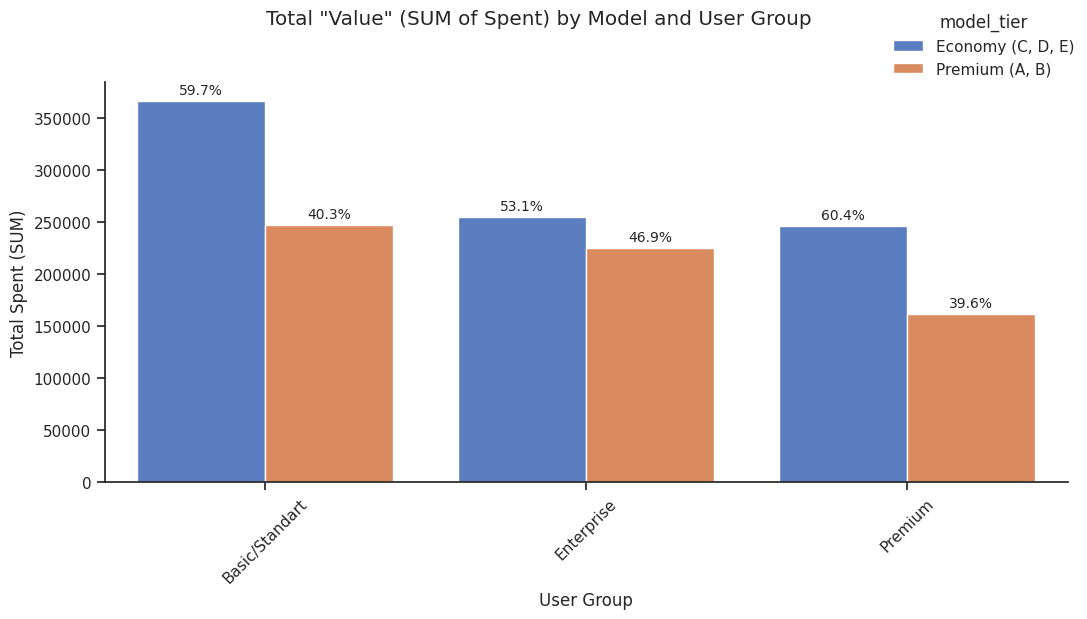

In [19]:
global_user_stats = df.groupby(['uuid', 'license', 'model']).agg(
        total_requests=('requests_cnt', 'sum'),
        total_spent=('spent_amount', 'sum'),
        active_days=('day_id', 'nunique')).reset_index()

uuids_to_highlight = global_user_stats['uuid'].unique()
title_suffix = "All Users"

enterprise_uuids = global_user_stats[global_user_stats['license'].isin(['Enterprise'])]['uuid'].unique()
premium_uuids = global_user_stats[global_user_stats['license'].isin(['Premium'])]['uuid'].unique()
all_uuids_series = global_user_stats['uuid']
basic_standart_uuids_series = all_uuids_series[~all_uuids_series.isin(enterprise_uuids) & ~all_uuids_series.isin(premium_uuids)]

has_overlap = np.isin(enterprise_uuids, premium_uuids).any()

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

if has_overlap:
    print("INSIGHT: The Enterprise and Premium user groups OVERLAP.")
    print("This means some users have been associated with both license types at some point.")
else:
    print("INSIGHT: The groups included in Enterprise and Premium OVERLAP (mutually exclusive).")
    print("This means users who have ever used Enterprise are a distinct group from those who have ever used Premium.")

economy_models = ['Model_C', 'Model_D', 'Model_E']

global_user_stats['model_tier'] = global_user_stats['model'].apply(
        lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)')

conditions = [global_user_stats['uuid'].isin(enterprise_uuids), 
            global_user_stats['uuid'].isin(premium_uuids),
            global_user_stats['uuid'].isin(basic_standart_uuids_series)]

choices = ['Enterprise', 'Premium', 'Basic/Standart']

global_user_stats['user_group'] = np.select(conditions, choices, default='Basic/Standard')
user_totals_by_group_tier = global_user_stats.groupby(
    ['user_group', 'model_tier', 'uuid']
)['total_spent'].sum().reset_index()

sns.set_theme(style="ticks", palette="pastel")

g = sns.catplot(
    data=user_totals_by_group_tier, 
    kind='bar',
    x='user_group',
    y='total_spent',
    hue='model_tier',
    estimator=sum,
    errorbar=None,
    palette="muted",
    height=6,
    aspect=1.5
)

ax = g.ax

group_totals = user_totals_by_group_tier.groupby('user_group')['total_spent'].sum()
group_labels = [tick.get_text() for tick in ax.get_xticklabels()]

patches = ax.patches

n_groups = len(group_labels)


for i, p in enumerate(patches):
    height = p.get_height()
    group_name = group_labels[i % n_groups]
    group_total = group_totals[group_name]

    if group_total > 0:
        percentage = (height / group_total) * 100
        label = f"{percentage:.1f}%"
        
    x = p.get_x() + p.get_width() / 2
    y = height + (ax.get_ylim()[1] * 0.01)
    
    if percentage > 0:
        ax.text(x, y, label, ha='center', va='bottom', fontsize=10)

sns.move_legend(g, "upper right")

g.set_axis_labels("User Group", "Total Spent (SUM)")
g.fig.suptitle('Total "Value" (SUM of Spent) by Model and User Group', y=1.03)
g.ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 5.4. Proof of Two Distinct Customer Strategies

A crucial data check confirms our hypothesis: the user groups (based on *ever* having an Enterprise license vs. *ever* having a Premium license) are **mutually exclusive**.

This is a powerful strategic insight. It means "Premium" is not simply a step before "Enterprise," but rather **two separate "end-states" for different customer profiles**. This strongly motivates our search for their different behavioral patterns.

This chart provides the first definitive proof of *how* their financial strategies differ:

* Both Enterprise and Premium users spend the majority of their budget on **Economy-Cost models** (Blue).
* However, the key difference is visible: **Enterprise users allocate significantly more of their capital (46.9%) to Premium-Cost models** (Orange) compared to Premium-license users (39.6%).

This confirms the two segments have different spending behaviors. We must now ask: in what specific scenarios does this difference appear? The next step is to analyze their session-level data to find the answer.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

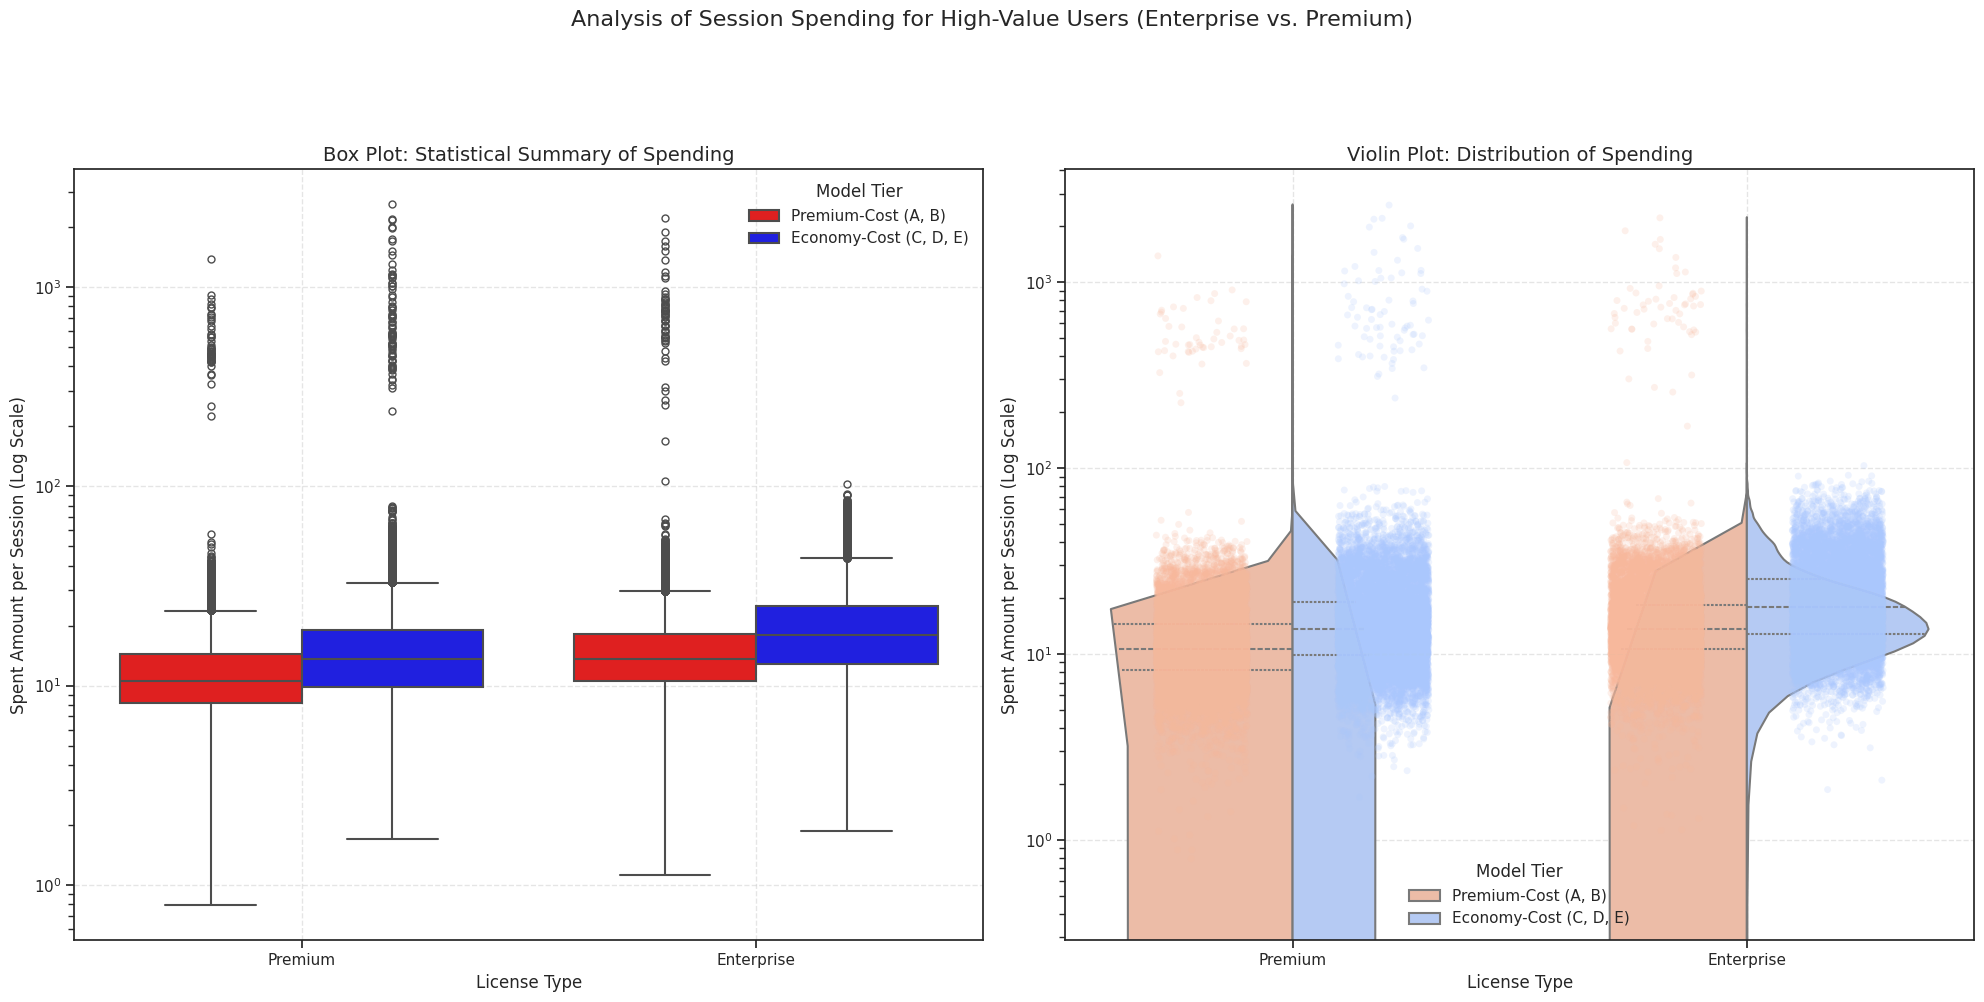

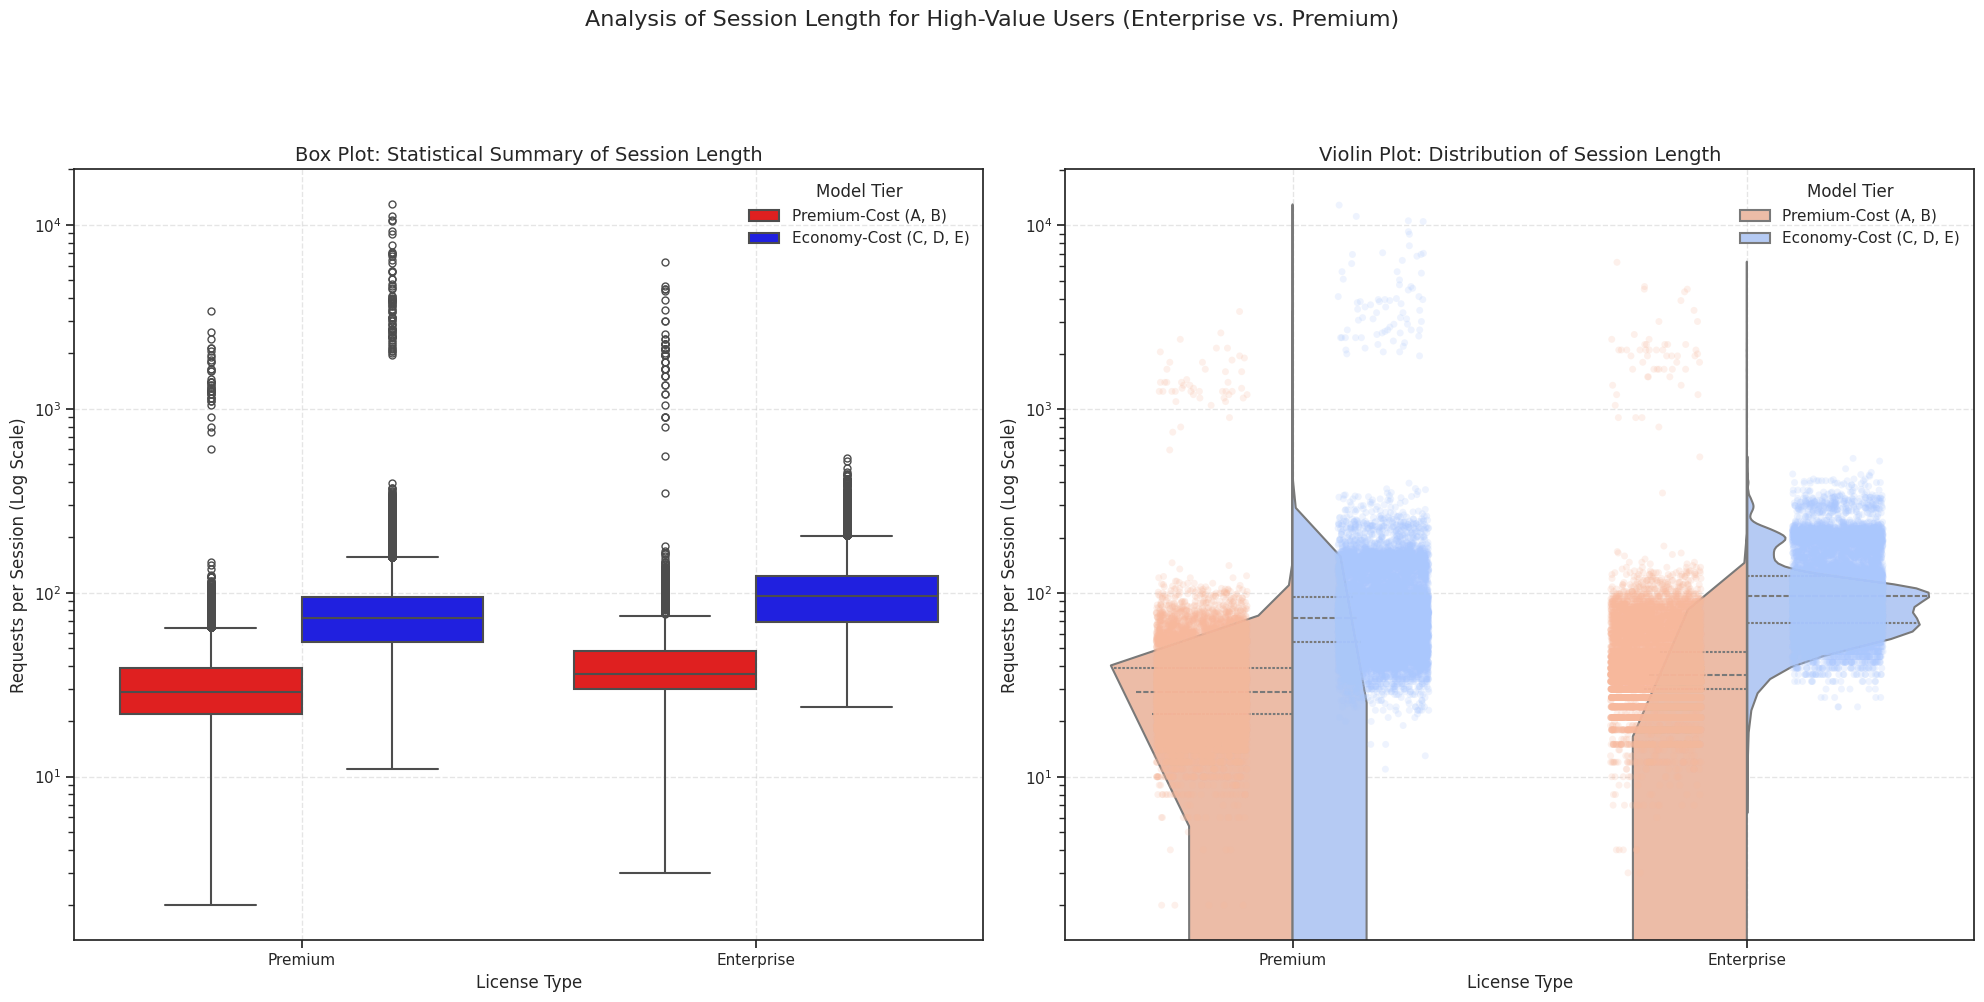

In [20]:
# Analysis of Session Spending
user_activity_analysis_df = df.merge(
    user_stats[['activity_level']], 
    left_on='uuid', 
    right_index=True,
    how='left'
)

premium_models_list = ['Model_A', 'Model_B']
user_activity_analysis_df['model_tier'] = user_activity_analysis_df['model'].apply(
    lambda x: 'Premium-Cost (A, B)' if x in premium_models_list else 'Economy-Cost (C, D, E)'
)

high_activity_df = user_activity_analysis_df[
    user_activity_analysis_df['activity_level'].isin(['High Activity', 'Very High Activity'])
]
target_licenses_df = high_activity_df[
    high_activity_df['license'].isin(['Enterprise', 'Premium'])
]


fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('Analysis of Session Spending for High-Value Users (Enterprise vs. Premium)', fontsize=16, y=1.03)

# Plot 1: Box Plot (spent_amount) 
ax1 = axes[0]
sns.boxplot(
    data=target_licenses_df,
    x='license',
    y='spent_amount',
    hue='model_tier',
    palette={'Premium-Cost (A, B)': '#FF0000', 'Economy-Cost (C, D, E)': '#0000FF'},
    linewidth=1.5,
    fliersize=5,
    ax=ax1
)
ax1.set_title("Box Plot: Statistical Summary of Spending", fontsize=14)
ax1.set_xlabel("License Type", fontsize=12)
ax1.set_ylabel("Spent Amount per Session (Log Scale)", fontsize=12)
ax1.set_yscale('log')
ax1.legend(title='Model Tier')
ax1.grid(True, which='major', linestyle='--', alpha=0.5)

# Plot 2: Violin Plot (spent_amount)
ax2 = axes[1]
sns.violinplot(
    data=target_licenses_df,
    x='license',
    y='spent_amount',
    hue='model_tier',
    split=True,
    inner='quartile',
    palette='coolwarm_r', 
    linewidth=1.5,
    ax=ax2
)
sns.stripplot(
    data=target_licenses_df,
    x='license',
    y='spent_amount',
    hue='model_tier',
    dodge=True,
    alpha=0.2,
    jitter=0.2,
    palette='coolwarm_r',
    legend=False,
    ax=ax2
)
ax2.set_title("Violin Plot: Distribution of Spending", fontsize=14)
ax2.set_xlabel("License Type", fontsize=12)
ax2.set_ylabel("Spent Amount per Session (Log Scale)", fontsize=12)
ax2.set_yscale('log')
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles[0:2], labels[0:2], title='Model Tier')
ax2.grid(True, which='major', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()




fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('Analysis of Session Length for High-Value Users (Enterprise vs. Premium)', fontsize=16, y=1.03)

# Plot 1: Box Plot (requests_cnt)
ax1 = axes[0]
sns.boxplot(
    data=target_licenses_df,
    x='license',
    y='requests_cnt', 
    hue='model_tier',
    palette={'Premium-Cost (A, B)': '#FF0000', 'Economy-Cost (C, D, E)': '#0000FF'},
    linewidth=1.5,
    fliersize=5, 
    ax=ax1
)
ax1.set_title("Box Plot: Statistical Summary of Session Length", fontsize=14)
ax1.set_xlabel("License Type", fontsize=12)
ax1.set_ylabel("Requests per Session (Log Scale)", fontsize=12)
ax1.set_yscale('log')
ax1.legend(title='Model Tier')
ax1.grid(True, which='major', linestyle='--', alpha=0.5)

# Plot 2: Violin Plot (requests_cnt)
ax2 = axes[1]
sns.violinplot(
    data=target_licenses_df,
    x='license',
    y='requests_cnt', 
    hue='model_tier',
    split=True,
    inner='quartile',
    palette='coolwarm_r', 
    linewidth=1.5,
    ax=ax2
)
sns.stripplot(
    data=target_licenses_df,
    x='license',
    y='requests_cnt', 
    hue='model_tier',
    dodge=True,
    alpha=0.2,
    jitter=0.2,
    palette='coolwarm_r',
    legend=False,
    ax=ax2
)
ax2.set_title("Violin Plot: Distribution of Session Length", fontsize=14)
ax2.set_xlabel("License Type", fontsize=12)
ax2.set_ylabel("Requests per Session (Log Scale)", fontsize=12)
ax2.set_yscale('log')
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles[0:2], labels[0:2], title='Model Tier')
ax2.grid(True, which='major', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 5.5. Key Insight: Different Strategies of High-Value Clients

The analysis of session-level behavior reveals fundamental differences between the two key segments.

* **Common Base (Optimization):** On average, Enterprise and Premium users behave very similarly. Most of their sessions are on Economy models, which suggests a general effort to optimize daily spending.

* **Enterprise Strategy (Paying for Quality):** The difference appears in high-value tasks. Enterprise clients are willing to spend significant resources on tasks that apparently require **long sessions**. This is confirmed by the analysis of *spending outliers*:
    * Enterprise has almost **no** expensive outlier sessions on Economy models.
    * At the same time, they show **very large spending outliers** on Premium models.

* **Premium Strategy (Paying for Volume):** Premium users demonstrate a different strategy. In their sessions with maximum spending (outliers), they use Premium models (apparently out of necessity) but **still give priority to Economy models**.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

## 6. Product Portfolio Analysis: Profiling Models, Features, and License Interactions

### 6.1. Interactive Dashboards: Analyzing User Value

This section moves from static plots to interactive dashboards designed for a dynamic, multi-dimensional exploration of user value.

* **Metrics Displayed:** The dashboards visualize the key relationship between **Total Spent** (Y-axis) and **Average Daily Activity** (X-axis) for each user.
* **Key Feature:** Powerful cohort filtering. You can "Include" or "Exclude" groups of users based on whether they were *ever* associated with a specific parameter (e.g., 'Model A' or 'Enterprise').
* **Purpose:** This feature allows for the isolation and analysis of the complete value profile for different cohorts, such as "all users who have ever held an Enterprise license."

In [21]:

global_user_stats = df.groupby(['uuid', 'license']).agg(
    total_requests=('requests_cnt', 'sum'),
    total_spent=('spent_amount', 'sum'),
    active_days=('day_id', 'nunique')
).reset_index()

global_user_stats = global_user_stats[global_user_stats['active_days'] > 0]
global_user_stats['avg_daily_requests'] = global_user_stats['total_requests'] / global_user_stats['active_days']

global_x_domain = (
    global_user_stats['avg_daily_requests'].min()*0.9,
    global_user_stats['avg_daily_requests'].max()*1.2
)
positive_spent = global_user_stats[global_user_stats['total_spent'] > 0]
global_y_domain = (
    positive_spent['total_spent'].min()*0.9 if not positive_spent.empty else 0.1,
    global_user_stats['total_spent'].max()*1.4
)

total_overall_revenue = df['spent_amount'].sum()


def create_final_plot_pro_style_final(licenses_to_filter, mode):
    if not licenses_to_filter:
        uuids_to_highlight = global_user_stats['uuid'].unique()
        title_suffix = "All Users"
    else:
        target_uuids = global_user_stats[global_user_stats['license'].isin(licenses_to_filter)]['uuid'].unique()
        if mode == 'Include':
            uuids_to_highlight = target_uuids
            title_suffix = f"Users who have had: {', '.join(licenses_to_filter)}"
        else:
            all_uuids = set(global_user_stats['uuid'].unique())
            target_uuids_set = set(target_uuids)
            uuids_to_highlight = list(all_uuids - target_uuids_set)
            title_suffix = f"Users who NEVER had: {', '.join(licenses_to_filter)}"

    source_data = global_user_stats.copy()
    source_data['group'] = np.where(
        source_data['uuid'].isin(uuids_to_highlight),
        source_data['license'],
        'Others'
    )
    
    scatter_plot = alt.Chart(source_data).mark_circle(
        stroke='white'
    ).encode(
        x=alt.X('avg_daily_requests:Q', scale=alt.Scale(type="log", domain=global_x_domain, zero=False), title='Average Daily Requests (Activity)'),
        y=alt.Y('total_spent:Q', scale=alt.Scale(type="log", domain=global_y_domain, zero=False), title='Total Spent ($)'),
        color=alt.Color('license:N', legend=alt.Legend(title="License Type")),
        size=alt.Size('total_spent:Q',
                      scale=alt.Scale(domain=global_y_domain, range=[50, 1000]),
                      legend=None),
        opacity=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0.08)),
        strokeWidth=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0)),
        order=alt.Order('z_order:Q'),
        tooltip=[
            'uuid:N', 'license:N',
            alt.Tooltip('total_spent:Q', format='$,.2f'),
            alt.Tooltip('avg_daily_requests:Q', format='.1f'),
            'active_days:Q'
        ]
    ).transform_calculate(
        z_order="datum.group != 'Others' ? 1 : 0"
    ).properties(
        title=f'User Value Analysis: {title_suffix}',
        width=650,
        height=500
    ).interactive()


    filtered_revenue = source_data[source_data['group'] != 'Others']['total_spent'].sum()
    percent_of_total_revenue = (filtered_revenue / total_overall_revenue) * 100 if total_overall_revenue > 0 else 0
    bar_chart = alt.Chart(source_data).mark_bar(width=50).encode(
        y=alt.Y('sum(total_spent):Q', scale=alt.Scale(domain=[0, total_overall_revenue]), axis=alt.Axis(title='Total Revenue ($)', format='~s')),
        x=alt.X('category:N', axis=None, title=''),
        color=alt.condition(alt.datum.group == 'Others', alt.value('lightgray'), alt.Color('group:N', legend=None)),
        order=alt.Order('sort_order:Q', sort='ascending'),
        tooltip=[
            alt.Tooltip('group:N', title='License Group'),
            alt.Tooltip('sum(total_spent):Q', title='Revenue', format='$,.0f'),
            alt.Tooltip('sum(total_requests):Q', title='Total Requests', format=',.0f'),
            alt.Tooltip('count(uuid):Q', title='Unique Users')
        ]
    ).transform_calculate(
        category='" "',
        sort_order="datum.group == 'Others' ? 1 : 0"
    ).properties(
        title=f"Contribution ({percent_of_total_revenue:.1f}% of Total)",
        width=50,
        height=450
    )

    table_data = source_data[source_data['group'] != 'Others'].groupby('group').agg(
        total_spent=('total_spent', 'sum'),
        total_requests=('total_requests', 'sum'),
        unique_users=('uuid', 'nunique')
    ).reset_index()

    if not table_data.empty and filtered_revenue > 0:
        table_data['percentage'] = (table_data['total_spent'] / filtered_revenue)
    else:
        table_data['percentage'] = 0

    base_table = alt.Chart(table_data).properties(width=150, title="Share of Filtered")

    common_tooltip = [
        alt.Tooltip('group:N', title='License Group'),
        alt.Tooltip('total_spent:Q', title='Revenue', format='$,.0f'),
        alt.Tooltip('total_requests:Q', title='Total Requests', format=',.0f'),
        alt.Tooltip('unique_users:Q', title='Unique Users')
    ]

    table_names = base_table.mark_text(align='left', dx=-80).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text='group:N',
        tooltip=common_tooltip
    )
    table_percents = base_table.mark_text(align='left', dx=10).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text=alt.Text('percentage:Q', format='.1%'),
        tooltip=common_tooltip
    )
    summary_table = (table_names + table_percents)



    dashboard = (scatter_plot | bar_chart | summary_table).properties(
        title=alt.TitleParams(text='User Value Interactive Dashboard', anchor='middle', fontSize=18)
    ).configure_view(
        stroke=None 
    )

    return dashboard





all_licenses = sorted(df['license'].unique().tolist())

interact(
    create_final_plot_pro_style_final,
    licenses_to_filter=widgets.SelectMultiple(
        options=all_licenses,
        value=['Premium', 'Enterprise'],
        description='Filter by Licenses:',
        style={'description_width': 'initial'},
        layout=Layout(width='50%')
    ),
    mode=widgets.RadioButtons(
        options=['Include', 'Exclude'],
        value='Include',
        description='Filter Mode:',
        style={'description_width': 'initial'}
    )
);

interactive(children=(SelectMultiple(description='Filter by Licenses:', index=(2, 1), layout=Layout(width='50%…

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 6.1 Hypothesis from License Cohort Analysis: "big players" first test their core use cases

By filtering the dashboard to focus on our Enterprise and Premium cohorts (users who *ever* held these licenses), a clear pattern emerges.

1.  We observe that these high-value users also recorded a small amount of activity (less than 2% of their total) under the **Basic** and **Standard** licenses.
2.  Their activity patterns during these "test" sessions appear comparable to the general usage patterns observed once they converted to their primary license type.

**Hypothesis:** This suggests a distinct user journey for our high-value clients. It's likely that these "big players" first **test their core use cases** on standard, low-commitment licenses to validate the product's fit. Once proven, they convert to the full Enterprise or Premium tier. We will check for this pattern in the **Temporal Trends** analysis.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

In [22]:
global_user_stats_model = df.groupby(['uuid', 'model']).agg(
    total_requests=('requests_cnt', 'sum'),
    total_spent=('spent_amount', 'sum'),
    active_days=('day_id', 'nunique')
).reset_index()

global_user_stats_model = global_user_stats_model[global_user_stats_model['active_days'] > 0]
global_user_stats_model['avg_daily_requests'] = global_user_stats_model['total_requests'] / global_user_stats_model['active_days']

global_x_domain_model = (
    global_user_stats_model['avg_daily_requests'].min() * 0.9,
    global_user_stats_model['avg_daily_requests'].max() * 1.2
)
positive_spent_model = global_user_stats_model[global_user_stats_model['total_spent'] > 0]
global_y_domain_model = (
    positive_spent_model['total_spent'].min() * 0.9 if not positive_spent_model.empty else 0.1,
    global_user_stats_model['total_spent'].max() * 1.4
)

total_overall_revenue = df['spent_amount'].sum()

def create_model_report(models_to_filter, mode):
    if not models_to_filter:
        uuids_to_highlight = global_user_stats_model['uuid'].unique()
        title_suffix = "All Users"
    else:
        target_uuids = global_user_stats_model[global_user_stats_model['model'].isin(models_to_filter)]['uuid'].unique()
        if mode == 'Include':
            uuids_to_highlight = target_uuids
            title_suffix = f"Users who have used: {', '.join(models_to_filter)}"
        else:
            all_uuids = set(global_user_stats_model['uuid'].unique())
            target_uuids_set = set(target_uuids)
            uuids_to_highlight = list(all_uuids - target_uuids_set)
            title_suffix = f"Users who NEVER used: {', '.join(models_to_filter)}"

    source_data = global_user_stats_model.copy()
    source_data['group'] = np.where(
        source_data['uuid'].isin(uuids_to_highlight),
        source_data['model'],
        'Others'
    )
    
    scatter_plot = alt.Chart(source_data).mark_circle(
        stroke='white'
    ).encode(
        x=alt.X('avg_daily_requests:Q', scale=alt.Scale(type="log", domain=global_x_domain_model, zero=False), title='Average Daily Requests (Activity)'),
        y=alt.Y('total_spent:Q', scale=alt.Scale(type="log", domain=global_y_domain_model, zero=False), title='Total Spent ($)'),
        color=alt.Color('model:N', legend=alt.Legend(title="Model Type")),
        size=alt.Size('total_spent:Q',
                      scale=alt.Scale(domain=global_y_domain_model, range=[50, 1000]),
                      legend=None),
        opacity=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0.08)),
        strokeWidth=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0)),
        order=alt.Order('z_order:Q'),
        tooltip=[
            'uuid:N', 'model:N',
            alt.Tooltip('total_spent:Q', format='$,.2f'),
            alt.Tooltip('avg_daily_requests:Q', format='.1f'),
            'active_days:Q'
        ]
    ).transform_calculate(
        z_order="datum.group != 'Others' ? 1 : 0"
    ).properties(
        title=f'User Value Analysis by Model: {title_suffix}',
        width=650,
        height=500
    ).interactive()

    filtered_revenue = source_data[source_data['group'] != 'Others']['total_spent'].sum()
    percent_of_total_revenue = (filtered_revenue / total_overall_revenue) * 100 if total_overall_revenue > 0 else 0
    bar_chart = alt.Chart(source_data).mark_bar(width=50).encode(
        y=alt.Y('sum(total_spent):Q', scale=alt.Scale(domain=[0, total_overall_revenue]), axis=alt.Axis(title='Total Revenue ($)', format='~s')),
        x=alt.X('category:N', axis=None, title=''),
        color=alt.condition(alt.datum.group == 'Others', alt.value('lightgray'), alt.Color('group:N', legend=None)),
        order=alt.Order('sort_order:Q', sort='ascending'),
        tooltip=[
            alt.Tooltip('group:N', title='Model Group'),
            alt.Tooltip('sum(total_spent):Q', title='Revenue', format='$,.0f'),
            alt.Tooltip('sum(total_requests):Q', title='Total Requests', format=',.0f'),
            alt.Tooltip('count(uuid):Q', title='Unique Users')
        ]
    ).transform_calculate(
        category='" "',
        sort_order="datum.group == 'Others' ? 1 : 0"
    ).properties(
        title=f"Contribution ({percent_of_total_revenue:.1f}% of Total)",
        width=50
    )

    table_data = source_data[source_data['group'] != 'Others'].groupby('group').agg(
        total_spent=('total_spent', 'sum'),
        total_requests=('total_requests', 'sum'),
        unique_users=('uuid', 'nunique')
    ).reset_index()

    if not table_data.empty and filtered_revenue > 0:
        table_data['percentage'] = (table_data['total_spent'] / filtered_revenue)
    else:
        table_data['percentage'] = 0

    base_table = alt.Chart(table_data).properties(width=150, title="Share of Filtered")

    common_tooltip = [
        alt.Tooltip('group:N', title='Model Group'),
        alt.Tooltip('total_spent:Q', title='Revenue', format='$,.0f'),
        alt.Tooltip('total_requests:Q', title='Total Requests', format=',.0f'),
        alt.Tooltip('unique_users:Q', title='Unique Users')
    ]

    table_names = base_table.mark_text(align='left', dx=-80).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text='group:N',
        tooltip=common_tooltip
    )
    table_percents = base_table.mark_text(align='left', dx=10).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text=alt.Text('percentage:Q', format='.1%'),
        tooltip=common_tooltip
    )
    summary_table = (table_names + table_percents)

    dashboard = (scatter_plot | bar_chart | summary_table).properties(
        title=alt.TitleParams(text='User Value Interactive Dashboard by Model', anchor='middle', fontSize=18)
    ).configure_view(
        stroke=None 
    )

    return dashboard

all_models = sorted(df['model'].unique().tolist())

interact(
    create_model_report,
    models_to_filter=widgets.SelectMultiple(
        options=all_models,
        value=[all_models[0]] if all_models else [],
        description='Filter by Models:',
        style={'description_width': 'initial'},
        layout=Layout(width='50%')
    ),
    mode=widgets.RadioButtons(
        options=['Include', 'Exclude'],
        value='Include',
        description='Filter Mode:',
        style={'description_width': 'initial'}
    )
);

interactive(children=(SelectMultiple(description='Filter by Models:', index=(0,), layout=Layout(width='50%'), …

In [23]:
# Model vs Feature combinations analysis
print("MODEL vs FEATURE COMBINATIONS")
print("=" * 50)

# Create cross-tabulation for model-feature combinations
model_feature_pivot = df.pivot_table(
    values=['requests_cnt', 'spent_amount'], 
    index='model', 
    columns='feature', 
    aggfunc='sum', 
    fill_value=0
)

# Requests by model-feature combination
print("\nTotal Requests by Model-Feature Combinations:")
requests_pivot = model_feature_pivot['requests_cnt']
print(requests_pivot.round(0).astype(int))

# Revenue by model-feature combination
print("\nTotal Revenue by Model-Feature Combinations:")
revenue_pivot = model_feature_pivot['spent_amount']
print(revenue_pivot.round(2))

# Calculate market share for each combination
total_requests = df['requests_cnt'].sum()
total_revenue = df['spent_amount'].sum()

print(f"\nMarket Share by Model-Feature Combinations (% of total requests):")
market_share_requests = (requests_pivot / total_requests * 100).round(1)
print(market_share_requests)

# Identify top performing combinations
model_feature_summary = df.groupby(['model', 'feature']).agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reset_index()

model_feature_summary['revenue_share'] = (model_feature_summary['spent_amount'] / total_revenue * 100).round(1)
model_feature_summary = model_feature_summary.sort_values('spent_amount', ascending=False)

print(f"\nTop 10 Model-Feature Combinations by Revenue:")
for i, row in model_feature_summary.head(10).iterrows():
    print(f"  {row['model']} + {row['feature']}: ${row['spent_amount']:,.2f} ({row['revenue_share']}%)")

MODEL vs FEATURE COMBINATIONS

Total Requests by Model-Feature Combinations:
feature  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5
model                                                         
Model_A     363290     295124     231346      69566      32607
Model_B     241452     252778     184196      16497      35448
Model_C     937253     404161     358344     162050      79988
Model_D     798043     603601     251417     124580     116509
Model_E     329741     200811     110376      52162      40711

Total Revenue by Model-Feature Combinations:
feature  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5
model                                                         
Model_A  132156.26  108921.86   86720.72   25076.05   12202.19
Model_B   88108.55   94703.35   66621.11    5837.73   12895.34
Model_C  174753.50   76716.27   68348.54   31964.58   14838.85
Model_D  152775.56  114626.67   48922.41   22862.91   22419.68
Model_E   62715.29   37875.36   21351.73    9610.92    788

In [24]:
# License vs Model preferences analysis
print("LICENSE vs MODEL PREFERENCES")
print("=" * 50)

# License-model combinations
license_model_analysis = df.groupby(['license', 'model']).agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reset_index()

# Calculate preferences within each license type
license_model_prefs = df.groupby('license')['model'].value_counts(normalize=True).round(3) * 100

print("\nModel Preferences by License Type (% of requests within license):")
for license_type in df['license'].unique():
    print(f"\n{license_type} License:")
    license_data = license_model_prefs[license_type].sort_values(ascending=False)
    for model, percentage in license_data.items():
        print(f"  {model}: {percentage:.1f}%")

# Revenue per user by license-model combination
license_model_detailed = df.groupby(['license', 'model']).agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reset_index()

license_model_detailed['revenue_per_user'] = (license_model_detailed['spent_amount'] / license_model_detailed['uuid']).round(2)
license_model_detailed['requests_per_user'] = (license_model_detailed['requests_cnt'] / license_model_detailed['uuid']).round(1)

print(f"\nRevenue per User by License-Model Combinations:")
top_combinations = license_model_detailed.sort_values('revenue_per_user', ascending=False).head(10)
for i, row in top_combinations.iterrows():
    print(f"  {row['license']} + {row['model']}: ${row['revenue_per_user']}/user ({row['requests_per_user']} req/user)")

LICENSE vs MODEL PREFERENCES

Model Preferences by License Type (% of requests within license):

Premium License:
  Model_A: 26.7%
  Model_B: 21.6%
  Model_C: 20.9%
  Model_D: 17.8%
  Model_E: 13.0%

Basic License:
  Model_A: 33.0%
  Model_D: 21.4%
  Model_C: 21.0%
  Model_B: 16.4%
  Model_E: 8.1%

Enterprise License:
  Model_A: 30.6%
  Model_C: 19.3%
  Model_D: 19.2%
  Model_B: 18.3%
  Model_E: 12.6%

Standard License:
  Model_A: 31.7%
  Model_D: 20.1%
  Model_B: 20.0%
  Model_C: 18.5%
  Model_E: 9.8%

Revenue per User by License-Model Combinations:
  Enterprise + Model_B: $1290.17/user (3510.9 req/user)
  Premium + Model_C: $1216.9/user (6439.8 req/user)
  Enterprise + Model_D: $1141.83/user (5962.4 req/user)
  Enterprise + Model_C: $1012.49/user (5357.0 req/user)
  Enterprise + Model_A: $997.42/user (2715.1 req/user)
  Premium + Model_A: $925.58/user (2505.0 req/user)
  Premium + Model_D: $909.05/user (4721.1 req/user)
  Premium + Model_B: $773.85/user (2105.6 req/user)
  Enterprise

In [25]:
# Feature usage patterns by license type
print("FEATURE USAGE BY LICENSE TYPE")
print("=" * 50)

# Feature preferences by license
license_feature_prefs = df.groupby('license')['feature'].value_counts(normalize=True).round(3) * 100

print("\nFeature Preferences by License Type (% of requests within license):")
for license_type in df['license'].unique():
    print(f"\n{license_type} License:")
    license_data = license_feature_prefs[license_type].sort_values(ascending=False)
    for feature, percentage in license_data.items():
        print(f"  {feature}: {percentage:.1f}%")

# Feature adoption rates by license
feature_adoption = df.groupby(['license', 'feature']).agg({
    'uuid': 'nunique'
}).reset_index()

# Get total users per license for adoption rate calculation
users_per_license = df.groupby('license')['uuid'].nunique()

feature_adoption_rates = []
for license_type in df['license'].unique():
    total_users = users_per_license[license_type]
    license_data = feature_adoption[feature_adoption['license'] == license_type]
    
    print(f"\nFeature Adoption Rates for {license_type} License:")
    for _, row in license_data.iterrows():
        adoption_rate = (row['uuid'] / total_users) * 100
        print(f"  {row['feature']}: {row['uuid']:,} users ({adoption_rate:.1f}% adoption)")

# Advanced segment analysis: Premium features vs Basic usage
print(f"\n" + "="*50)
print("ADVANCED INSIGHTS")
print("="*50)

# Cost efficiency by license-feature combinations
license_feature_efficiency = df.groupby(['license', 'feature']).agg({
    'cost_per_request': 'mean',
    'requests_cnt': 'sum',
    'spent_amount': 'sum'
}).round(3)

print(f"\nMost Cost-Efficient License-Feature Combinations:")
efficiency_ranking = license_feature_efficiency.sort_values('cost_per_request').head(10)
for (license_type, feature), stats in efficiency_ranking.iterrows():
    print(f"  {license_type} + {feature}: ${stats['cost_per_request']:.3f} per request")

FEATURE USAGE BY LICENSE TYPE

Feature Preferences by License Type (% of requests within license):

Premium License:
  Feature_1: 36.6%
  Feature_2: 29.6%
  Feature_3: 21.7%
  Feature_5: 6.3%
  Feature_4: 5.8%

Basic License:
  Feature_1: 37.3%
  Feature_2: 29.7%
  Feature_3: 21.5%
  Feature_4: 5.8%
  Feature_5: 5.6%

Enterprise License:
  Feature_1: 36.3%
  Feature_2: 29.6%
  Feature_3: 21.6%
  Feature_5: 6.3%
  Feature_4: 6.3%

Standard License:
  Feature_1: 37.3%
  Feature_2: 29.9%
  Feature_3: 21.0%
  Feature_5: 6.0%
  Feature_4: 5.8%

Feature Adoption Rates for Premium License:
  Feature_1: 247 users (100.0% adoption)
  Feature_2: 246 users (99.6% adoption)
  Feature_3: 246 users (99.6% adoption)
  Feature_4: 243 users (98.4% adoption)
  Feature_5: 244 users (98.8% adoption)

Feature Adoption Rates for Basic License:
  Feature_1: 687 users (95.8% adoption)
  Feature_2: 672 users (93.7% adoption)
  Feature_3: 653 users (91.1% adoption)
  Feature_4: 541 users (75.5% adoption)
  Feat

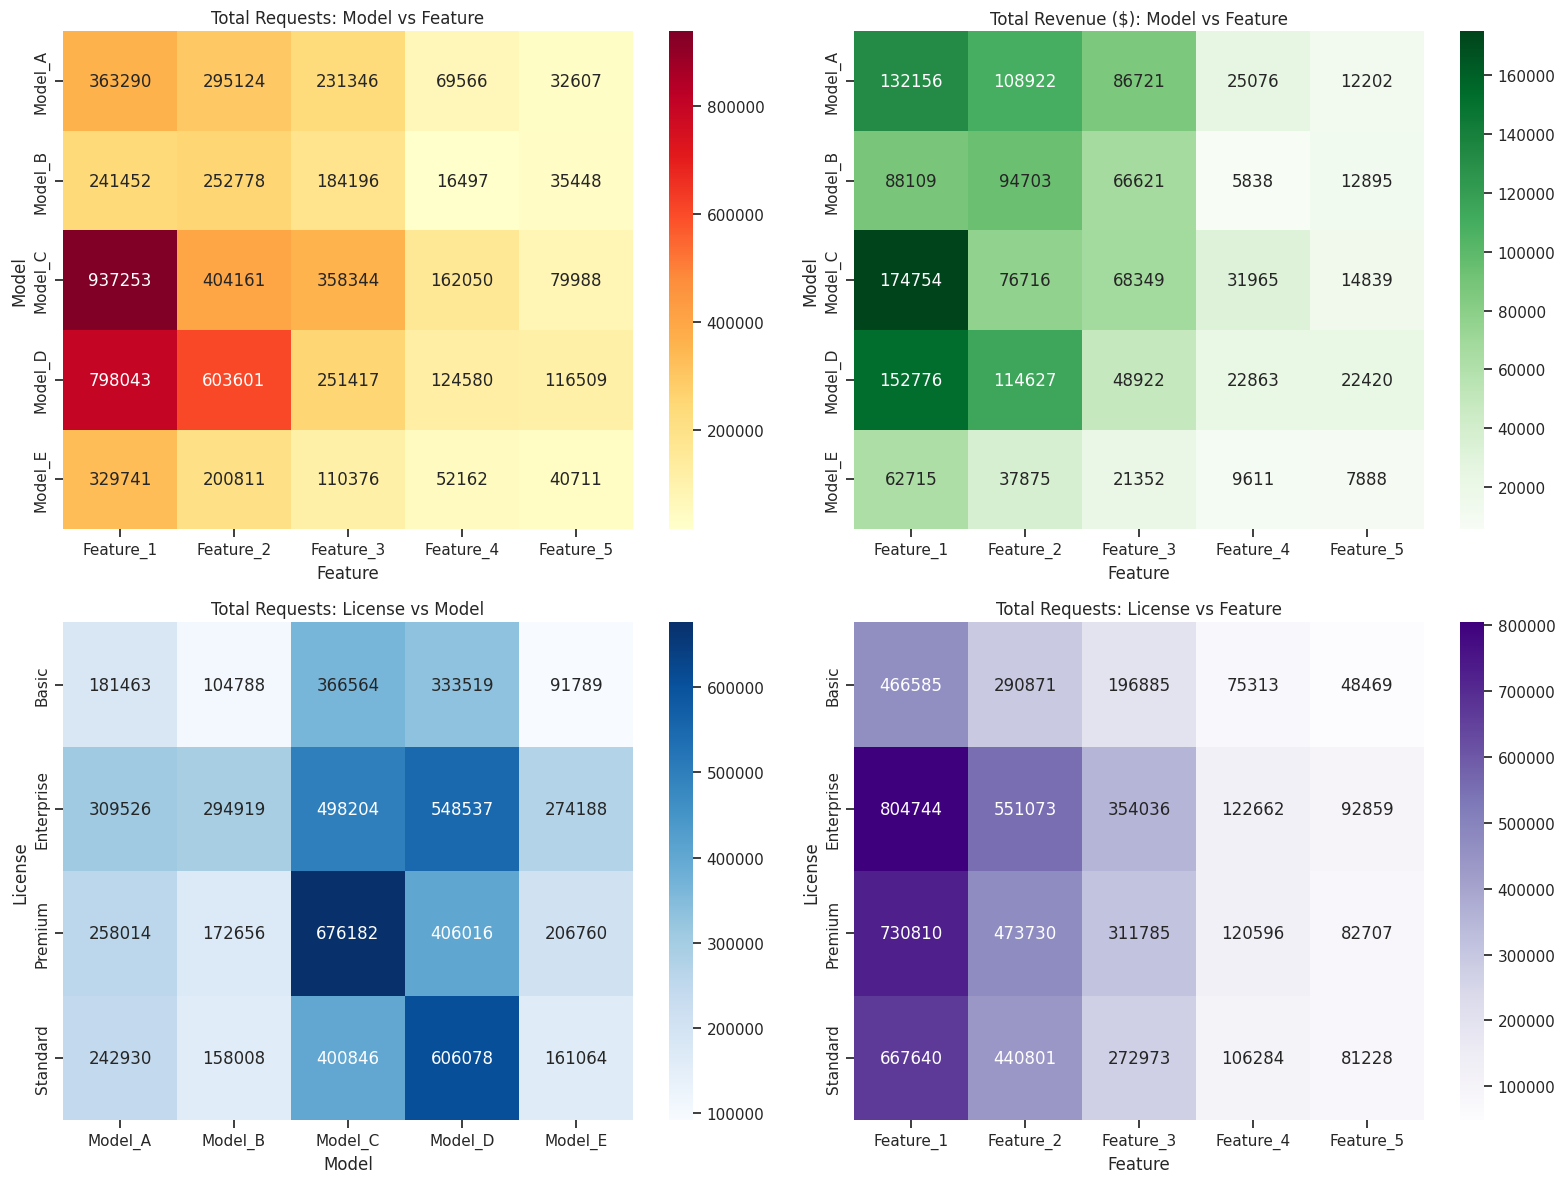

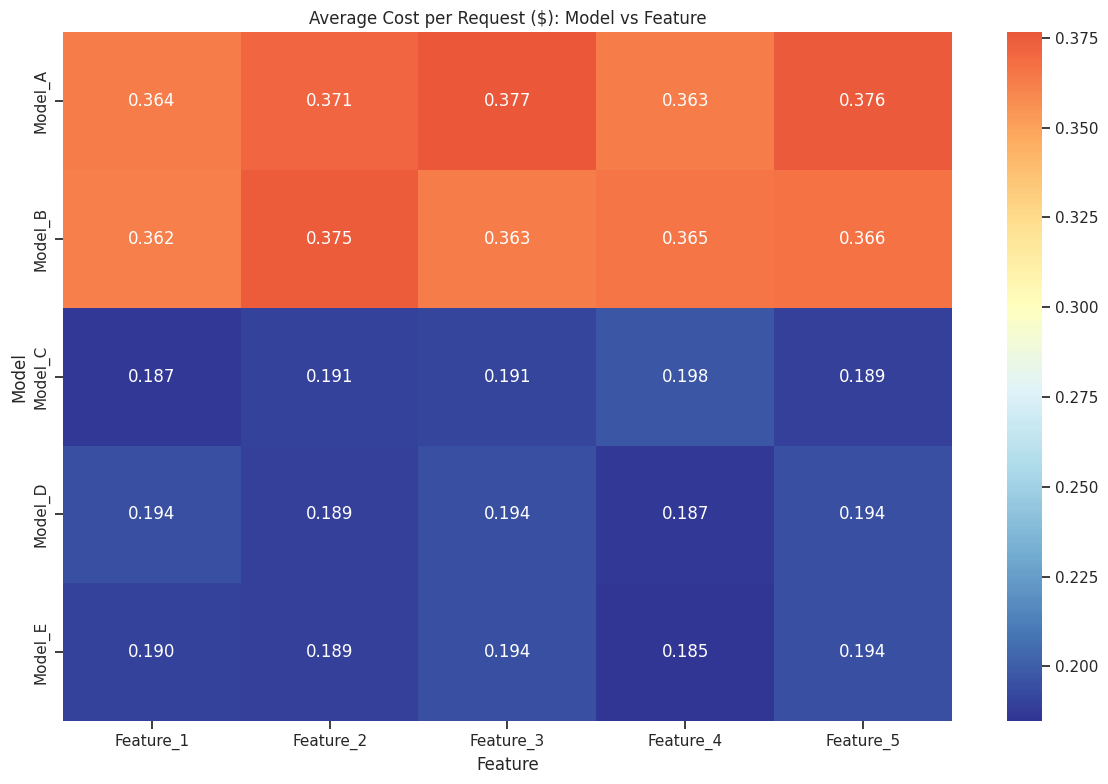

In [26]:
# Create comprehensive cross-dimensional heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Model-Feature requests heatmap
ax1 = axes[0, 0]
sns.heatmap(requests_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax1)
ax1.set_title('Total Requests: Model vs Feature')
ax1.set_xlabel('Feature')
ax1.set_ylabel('Model')

# Model-Feature revenue heatmap
ax2 = axes[0, 1]
sns.heatmap(revenue_pivot, annot=True, fmt='.0f', cmap='Greens', ax=ax2)
ax2.set_title('Total Revenue ($): Model vs Feature')
ax2.set_xlabel('Feature')
ax2.set_ylabel('Model')

# License-Model requests distribution
license_model_pivot = df.pivot_table(
    values='requests_cnt', 
    index='license', 
    columns='model', 
    aggfunc='sum', 
    fill_value=0
)
ax3 = axes[1, 0]
sns.heatmap(license_model_pivot, annot=True, fmt='.0f', cmap='Blues', ax=ax3)
ax3.set_title('Total Requests: License vs Model')
ax3.set_xlabel('Model')
ax3.set_ylabel('License')

# License-Feature requests distribution
license_feature_pivot = df.pivot_table(
    values='requests_cnt', 
    index='license', 
    columns='feature', 
    aggfunc='sum', 
    fill_value=0
)
ax4 = axes[1, 1]
sns.heatmap(license_feature_pivot, annot=True, fmt='.0f', cmap='Purples', ax=ax4)
ax4.set_title('Total Requests: License vs Feature')
ax4.set_xlabel('Feature')
ax4.set_ylabel('License')

plt.tight_layout()
plt.show()

# Additional visualization: Cost per request by combinations
plt.figure(figsize=(12, 8))
cost_per_request_pivot = df.pivot_table(
    values='cost_per_request', 
    index='model', 
    columns='feature', 
    aggfunc='mean', 
    fill_value=0
)
sns.heatmap(cost_per_request_pivot, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0.3)
plt.title('Average Cost per Request ($): Model vs Feature')
plt.xlabel('Feature')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 6.2. Product Portfolio Analysis: Model Strategy and Feature Hypothesis

This set of heatmaps and tables provides a complete profile of our product-market fit. The analysis reveals one clear insight and one critical hypothesis.

**Insight 1: The Model, Not the Feature, Defines the Cost**

This is the most direct and provable conclusion from the data. The "Average Cost per Request ($)" heatmap provides definitive proof.

* **Evidence:** Reading the heatmap horizontally, the cost for any single model is virtually identical across all five features. `Model_A` sessions consistently cost ~$0.37, regardless of the feature used. `Model_C`, `D`, and `E` sessions consistently cost ~$0.19.
* **Conclusion:** Users are paying for access to one of two "engines" (a Premium-Cost tier or an Economy-Cost tier). The features are simply the different ways to *use* that engine.

---

**Hypothesis 1: Are "Niche" Features Actually "Gateway" Features?**

The data on feature usage presents a critical hypothesis that requires further investigation.

* **The "Niche" Observation:** At first glance, `Feature_4` (5.9%) and `Feature_5` (6.0%) appear to be simple niche products. They are used far less frequently in terms of total request volume than the core features.
* **The Conflicting Data:** However, the "Feature Adoption Rates" tables tell a different story. Adoption of these "niche" features is nearly 100% among **Enterprise** (99.2%) and **Premium** (98.4%-98.8%) users. In contrast, **Basic** users have a significantly lower adoption rate (75.0%-75.5%).
* **Actionable Hypothesis:** This discrepancy suggests F4/F5 may not be *just* niche features, but rather "gateway features." Their usage may be a powerful **Product-Qualified Lead (PQL)** trigger. It is possible that a Basic/Standard user who begins using F4/F5 is signaling they are a "power user" ready for an upsell. This is a hypothesis, not a conclusion, and must be tested with a dedicated cohort analysis to confirm if adoption of F4/F5 correlates with a higher conversion rate to premium tiers.

---

**Insight 2: The Two-Pillar Revenue Engine**

Finally, the revenue heatmaps confirm the "Maximalist vs. Optimist" theory at the product level.

* **Evidence:** The "Total Requests" heatmap is dominated by Economy models (e.g., `Model_C + Feature_1`). However, the "Total Revenue" heatmap is far more balanced.
* **Top 3 Revenue Drivers:**
    1.  `Model_C + Feature_1` ($174k) - [Optimist: High-Volume, Low-Cost]
    2.  `Model_D + Feature_1` ($152k) - [Optimist: High-Volume, Low-Cost]
    3.  `Model_A + Feature_1` ($132k) - [Maximalist: Low-Volume, High-Cost]
* **Conclusion:** Our business revenue is balanced on two pillars. The high revenue from "Optimists" (using high-volume, low-cost models) is complemented by the high revenue from "Maximalists" (using lower-volume, high-cost models).

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

## 7. Temporal Trends Analysis

This section analyzes the daily, weekly, and monthly activity patterns to understand the business's rhythm and user habits.

### 7.1. Testing the "Test-and-Convert" Hypothesis

We will now test the hypothesis from Section 6.1. If "big players" first test on Basic/Standard licenses before converting, we should see this pattern in their temporal data.

We will isolate the Enterprise and Premium user cohorts (users who *ever* used these licenses) and analyze their *entire* license activity across the 3-month period. If the hypothesis is correct, their Basic/Standard activity should be concentrated at the beginning of the period and then decline as their Enterprise/Premium activity ramps up.

--- Starting Event-Based Analysis (Journey to Enterprise) ---
Count of enterprise cohort - 251
Count of base cohort - 1398
Count of cohort_a_uuids - 17


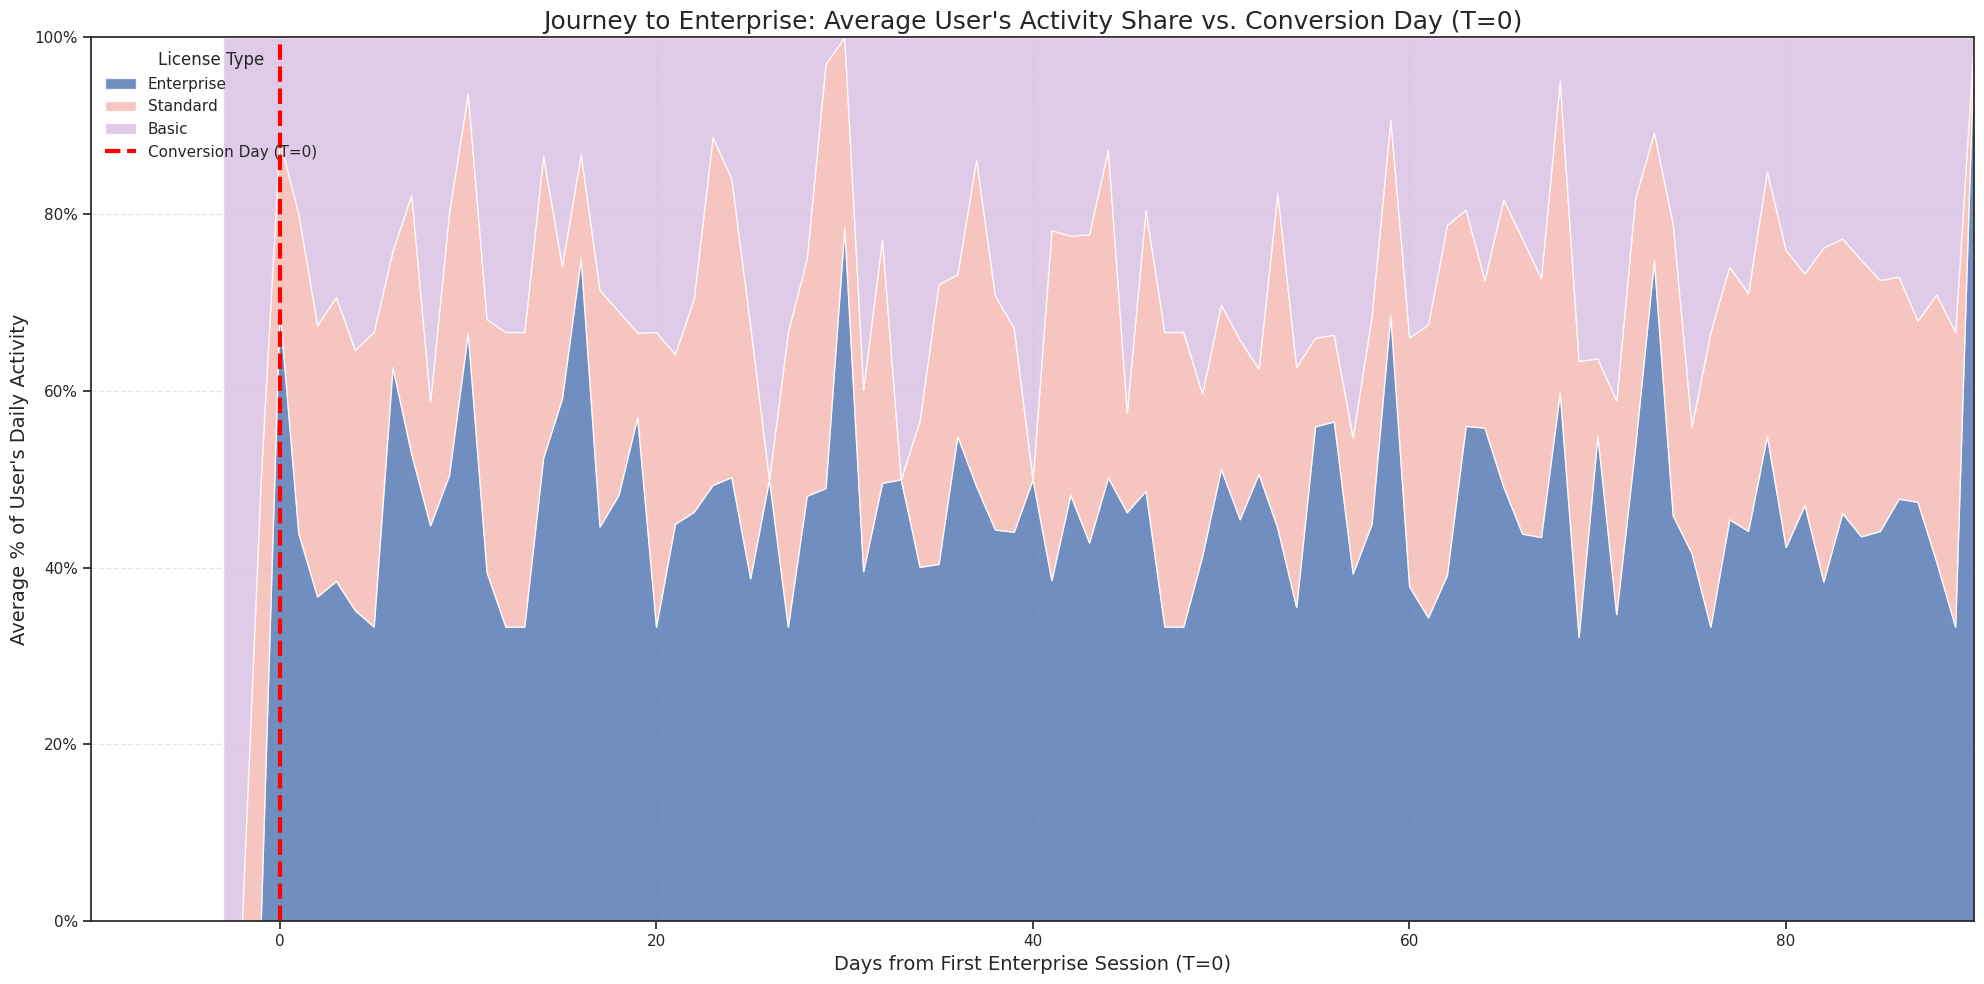


--- Starting Event-Based Analysis (Journey to Premium) ---
Count of premium cohort - 247
Count of base cohort - 1398
Count of cohort_b_uuids - 13


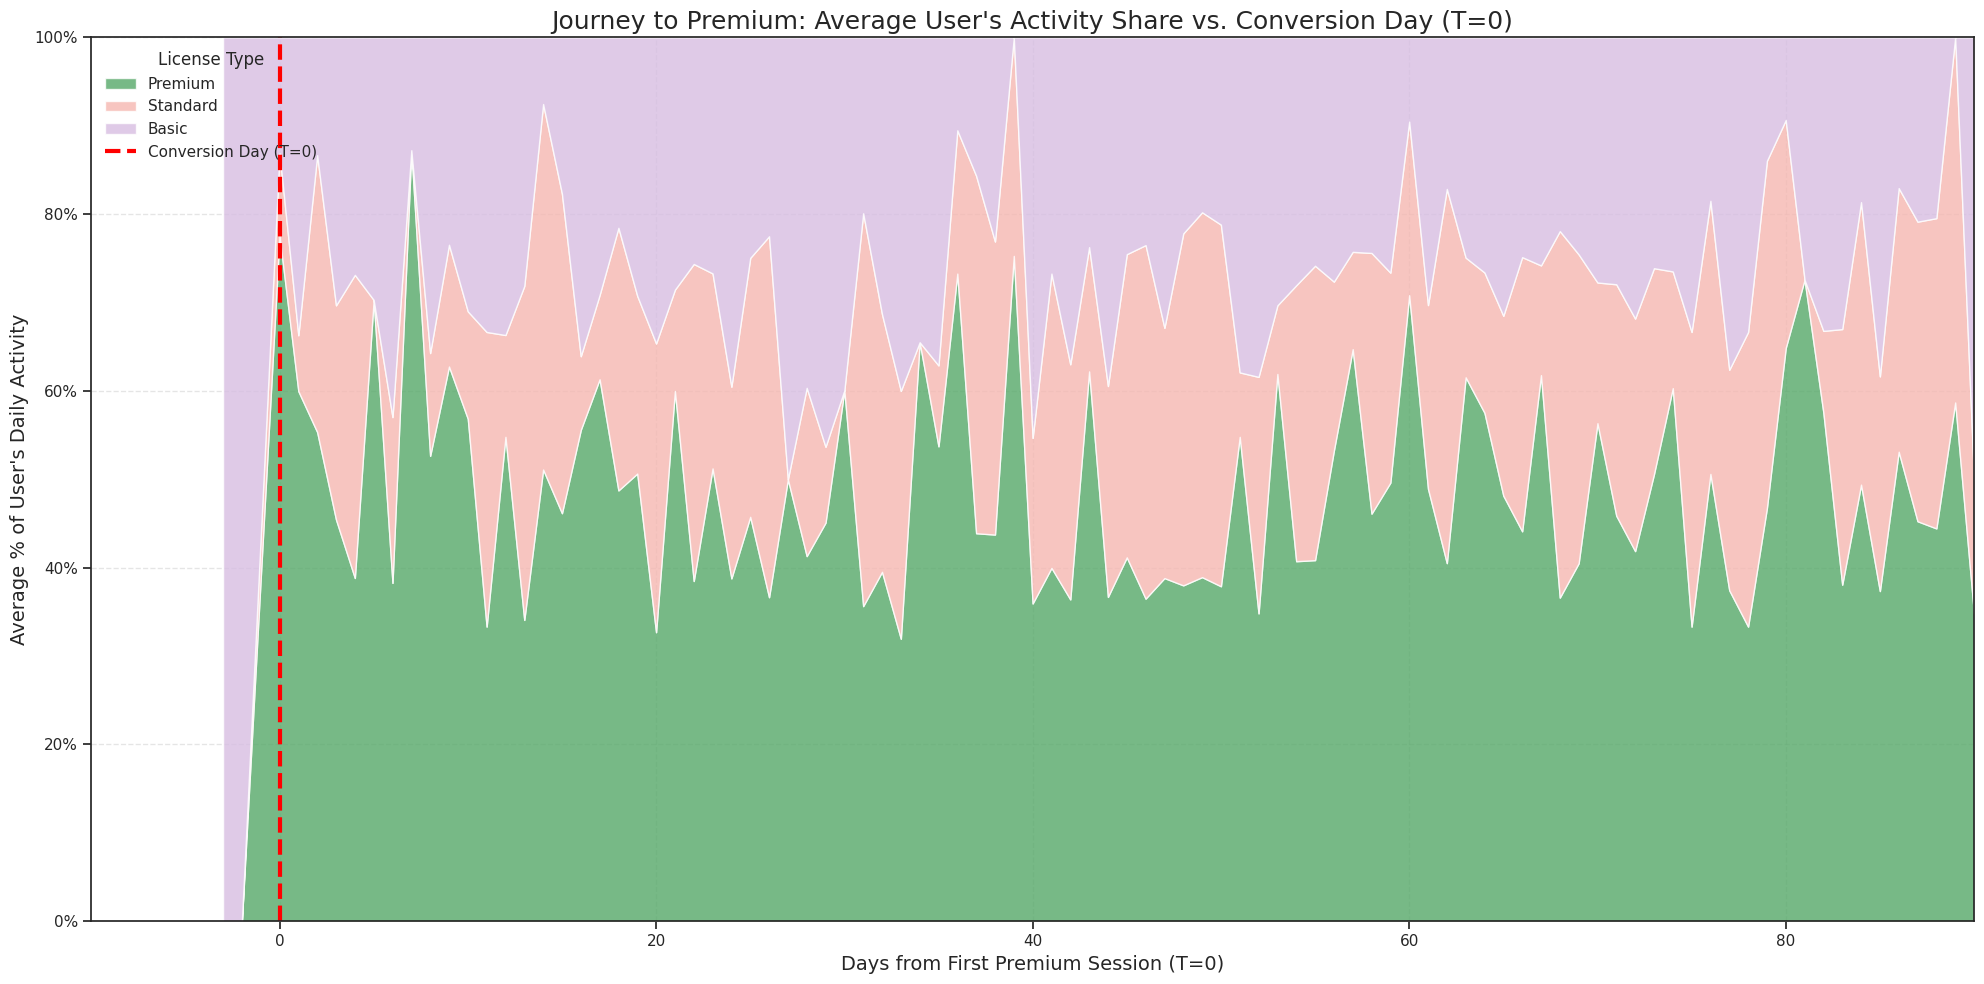

In [ ]:
print("--- Starting Event-Based Analysis (Journey to Enterprise) ---")

enterprise_uuids = set(df[df['license'] == 'Enterprise']['uuid'].unique())
print(f"Count of enterprise cohort - {len(enterprise_uuids)}")
base_uuids = set(df[df['license'].isin(['Basic', 'Standard'])]['uuid'].unique())
print(f"Count of base cohort - {len(base_uuids)}")

cohort_a_uuids = list(enterprise_uuids.intersection(base_uuids))
cohort_df = df[df['uuid'].isin(cohort_a_uuids)].copy()
print(f"Count of cohort_a_uuids - {len(cohort_a_uuids)}")

enterprise_sessions = cohort_df[cohort_df['license'] == 'Enterprise']
conversion_day_map = enterprise_sessions.groupby('uuid')['day_id'].min().reset_index()
conversion_day_map = conversion_day_map.rename(columns={'day_id': 'conversion_day'})

aligned_df = pd.merge(cohort_df, conversion_day_map, on='uuid', how='left')
aligned_df['days_from_conversion'] = (aligned_df['day_id'] - aligned_df['conversion_day']).dt.days

user_daily_total = aligned_df.groupby(['uuid', 'days_from_conversion'])['requests_cnt'].sum().reset_index()
user_daily_total = user_daily_total.rename(columns={'requests_cnt': 'total_user_requests'})

user_license_daily = aligned_df.groupby(['uuid', 'days_from_conversion', 'license'])['requests_cnt'].sum().reset_index()

norm_df = pd.merge(
    user_license_daily,
    user_daily_total,
    on=['uuid', 'days_from_conversion']
)

norm_df['user_activity_share'] = (norm_df['requests_cnt'] / norm_df['total_user_requests']).fillna(0)

final_trend = norm_df.groupby(['days_from_conversion', 'license'])['user_activity_share'].mean().reset_index()

final_pivot = final_trend.pivot_table(
    index='days_from_conversion',
    columns='license',
    values='user_activity_share',
    fill_value=0
)

final_pivot_total = final_pivot.sum(axis=1)
final_percentage = final_pivot.divide(final_pivot_total, axis=0).fillna(0)

final_percentage = final_percentage.loc[-10:90]

license_order = ['Enterprise', 'Standard', 'Basic']
for lic in license_order:
    if lic not in final_percentage.columns:
        final_percentage[lic] = 0
final_percentage = final_percentage[license_order]

colors = ['#4C72B0', '#F5B7B1', '#D7BDE2']

plt.figure(figsize=(20, 10))
plt.stackplot(
    final_percentage.index,
    [final_percentage[col] for col in license_order],
    labels=license_order,
    colors=colors,
    alpha=0.8
)

plt.axvline(x=0, color='red', linestyle='--', linewidth=3, label='Conversion Day (T=0)')
plt.title('Journey to Enterprise: Average User\'s Activity Share vs. Conversion Day (T=0)', fontsize=18)
plt.xlabel(f'Days from First Enterprise Session (T=0)', fontsize=14)
plt.ylabel('Average % of User\'s Daily Activity', fontsize=14)
plt.legend(loc='upper left', title='License Type')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-10, 90)
plt.ylim(0, 1)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()


print("\n--- Starting Event-Based Analysis (Journey to Premium) ---")

premium_uuids = set(df[df['license'] == 'Premium']['uuid'].unique())
print(f"Count of premium cohort - {len(premium_uuids)}")
base_uuids = set(df[df['license'].isin(['Basic', 'Standard'])]['uuid'].unique())
print(f"Count of base cohort - {len(base_uuids)}")

cohort_b_uuids = list(premium_uuids.intersection(base_uuids))
cohort_df = df[df['uuid'].isin(cohort_b_uuids)].copy()
print(f"Count of cohort_b_uuids - {len(cohort_b_uuids)}")

premium_sessions = cohort_df[cohort_df['license'] == 'Premium']
conversion_day_map = premium_sessions.groupby('uuid')['day_id'].min().reset_index()
conversion_day_map = conversion_day_map.rename(columns={'day_id': 'conversion_day'})

aligned_df = pd.merge(cohort_df, conversion_day_map, on='uuid', how='left')
aligned_df['days_from_conversion'] = (aligned_df['day_id'] - aligned_df['conversion_day']).dt.days

user_daily_total = aligned_df.groupby(['uuid', 'days_from_conversion'])['requests_cnt'].sum().reset_index()
user_daily_total = user_daily_total.rename(columns={'requests_cnt': 'total_user_requests'})

user_license_daily = aligned_df.groupby(['uuid', 'days_from_conversion', 'license'])['requests_cnt'].sum().reset_index()

norm_df = pd.merge(
    user_license_daily,
    user_daily_total,
    on=['uuid', 'days_from_conversion']
)

norm_df['user_activity_share'] = (norm_df['requests_cnt'] / norm_df['total_user_requests']).fillna(0)

final_trend = norm_df.groupby(['days_from_conversion', 'license'])['user_activity_share'].mean().reset_index()

final_pivot = final_trend.pivot_table(
    index='days_from_conversion',
    columns='license',
    values='user_activity_share',
    fill_value=0
)

final_pivot_total = final_pivot.sum(axis=1)
final_percentage = final_pivot.divide(final_pivot_total, axis=0).fillna(0)

final_percentage = final_percentage.loc[-10:90]

license_order = ['Premium', 'Standard', 'Basic']
for lic in license_order:
    if lic not in final_percentage.columns:
        final_percentage[lic] = 0
final_percentage = final_percentage[license_order]

colors = ['#55A868', '#F5B7B1', '#D7BDE2']

plt.figure(figsize=(20, 10))
plt.stackplot(
    final_percentage.index,
    [final_percentage[col] for col in license_order],
    labels=license_order,
    colors=colors,
    alpha=0.8
)

plt.axvline(x=0, color='red', linestyle='--', linewidth=3, label='Conversion Day (T=0)')
plt.title('Journey to Premium: Average User\'s Activity Share vs. Conversion Day (T=0)', fontsize=18)
plt.xlabel(f'Days from First Premium Session (T=0)', fontsize=14)
plt.ylabel('Average % of User\'s Daily Activity', fontsize=14)
plt.legend(loc='upper left', title='License Type')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-10, 90)
plt.ylim(0, 1)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

sns.set_palette("husl")

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 7.1. Finding: "Test and Convert" Hypothesis Rejected

The "Basic/Standard -> Premium/Enterprise" hypothesis is **rejected**.

* **The Data:**
    * **Enterprise Cohort:** Only **17 out of 251** (6.8%) Enterprise users ever used Basic/Standard.
    * **Premium Cohort:** Only **13 out of 247** (5.3%) Premium users ever used Basic/Standard.

* **The Insight:**
    1.  The number of "migrating" users is **statistically insignificant**.
    2.  This group (30 users) is the source of the 1-2% "noise" we saw earlier.
    3.  **Conclusion:** The customer pools (Basic/Standard vs. Enterprise/Premium) are **two different audiences**, not one converting into the other.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 7.2. Observation: The "Weekday Pattern"

Analysis of the aggregated time-series charts (like `Daily Requests Trend` and `Daily Active Users`)

In [28]:
# Daily trends analysis
print("DAILY TRENDS ANALYSIS")
print("=" * 50)

# Daily aggregations
daily_trends = df.groupby('day_id').agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reset_index()

daily_trends.columns = ['date', 'total_requests', 'total_revenue', 'active_users']
daily_trends['avg_requests_per_user'] = (daily_trends['total_requests'] / daily_trends['active_users']).round(1)
daily_trends['avg_revenue_per_user'] = (daily_trends['total_revenue'] / daily_trends['active_users']).round(2)

print(f"\nDaily Activity Summary:")
print(f"  Average daily requests: {daily_trends['total_requests'].mean():,.0f}")
print(f"  Average daily revenue: ${daily_trends['total_revenue'].mean():,.2f}")
print(f"  Average daily active users: {daily_trends['active_users'].mean():,.0f}")
print(f"  Peak day requests: {daily_trends['total_requests'].max():,} ({daily_trends.loc[daily_trends['total_requests'].idxmax(), 'date'].strftime('%Y-%m-%d')})")
print(f"  Peak day revenue: ${daily_trends['total_revenue'].max():,.2f} ({daily_trends.loc[daily_trends['total_revenue'].idxmax(), 'date'].strftime('%Y-%m-%d')})")

# Day of week analysis
daily_trends['day_of_week'] = daily_trends['date'].dt.day_name()
daily_trends['day_of_week_num'] = daily_trends['date'].dt.dayofweek

dow_analysis = daily_trends.groupby('day_of_week').agg({
    'total_requests': 'mean',
    'total_revenue': 'mean',
    'active_users': 'mean'
}).round(2)

# Sort by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_analysis = dow_analysis.reindex(day_order)

print(f"\nDay of Week Patterns:")
for day, stats in dow_analysis.iterrows():
    print(f"  {day}: {stats['total_requests']:,.0f} requests, ${stats['total_revenue']:,.2f} revenue, {stats['active_users']:,.0f} users")

DAILY TRENDS ANALYSIS

Daily Activity Summary:
  Average daily requests: 68,392
  Average daily revenue: $16,314.28
  Average daily active users: 716
  Peak day requests: 121,083 (2025-05-07)
  Peak day revenue: $28,232.01 (2025-04-17)

Day of Week Patterns:
  Monday: 86,522 requests, $20,818.69 revenue, 914 users
  Tuesday: 88,080 requests, $20,819.93 revenue, 883 users
  Wednesday: 84,709 requests, $20,075.44 revenue, 891 users
  Thursday: 84,404 requests, $20,408.15 revenue, 897 users
  Friday: 91,259 requests, $21,722.39 revenue, 928 users
  Saturday: 25,362 requests, $5,963.24 revenue, 269 users
  Sunday: 21,717 requests, $5,188.32 revenue, 266 users


In [29]:
# Weekly and monthly trends
print("WEEKLY AND MONTHLY TRENDS")
print("=" * 50)

# Weekly trends
weekly_trends = df.groupby(['year', 'week_number']).agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reset_index()

weekly_trends.columns = ['year', 'week', 'total_requests', 'total_revenue', 'active_users']
weekly_trends['week_id'] = weekly_trends['year'].astype(str) + '-W' + weekly_trends['week'].astype(str).str.zfill(2)

print(f"\nWeekly Trends:")
print(f"  Total weeks analyzed: {len(weekly_trends)}")
print(f"  Average weekly requests: {weekly_trends['total_requests'].mean():,.0f}")
print(f"  Average weekly revenue: ${weekly_trends['total_revenue'].mean():,.2f}")
print(f"  Best performing week: {weekly_trends.loc[weekly_trends['total_revenue'].idxmax(), 'week_id']} (${weekly_trends['total_revenue'].max():,.2f})")

# Monthly trends 
monthly_trends = df.groupby('month_name').agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reindex(['March', 'April', 'May'])

monthly_trends.columns = ['total_requests', 'total_revenue', 'active_users']
monthly_trends['avg_requests_per_user'] = (monthly_trends['total_requests'] / monthly_trends['active_users']).round(1)
monthly_trends['avg_revenue_per_user'] = (monthly_trends['total_revenue'] / monthly_trends['active_users']).round(2)

print(f"\nMonthly Growth Analysis:")
for month, stats in monthly_trends.iterrows():
    print(f"\n{month}:")
    print(f"  Total requests: {stats['total_requests']:,}")
    print(f"  Total revenue: ${stats['total_revenue']:,.2f}")
    print(f"  Active users: {stats['active_users']:,}")
    print(f"  Requests per user: {stats['avg_requests_per_user']}")
    print(f"  Revenue per user: ${stats['avg_revenue_per_user']}")

# Calculate month-over-month growth
print(f"\nMonth-over-Month Growth:")
for i in range(1, len(monthly_trends)):
    current_month = monthly_trends.index[i]
    prev_month = monthly_trends.index[i-1]
    
    revenue_growth = ((monthly_trends.loc[current_month, 'total_revenue'] - monthly_trends.loc[prev_month, 'total_revenue']) / monthly_trends.loc[prev_month, 'total_revenue'] * 100)
    requests_growth = ((monthly_trends.loc[current_month, 'total_requests'] - monthly_trends.loc[prev_month, 'total_requests']) / monthly_trends.loc[prev_month, 'total_requests'] * 100)
    
    print(f"  {prev_month} to {current_month}: {revenue_growth:+.1f}% revenue, {requests_growth:+.1f}% requests")

WEEKLY AND MONTHLY TRENDS

Weekly Trends:
  Total weeks analyzed: 14
  Average weekly requests: 449,432
  Average weekly revenue: $107,208.10
  Best performing week: 2025-W21 ($137,326.90)

Monthly Growth Analysis:

March:
  Total requests: 1,668,402.0
  Total revenue: $403,473.18
  Active users: 1,455.0
  Requests per user: 1146.7
  Revenue per user: $277.3

April:
  Total requests: 2,056,461.0
  Total revenue: $494,638.82
  Active users: 1,638.0
  Requests per user: 1255.5
  Revenue per user: $301.98

May:
  Total requests: 2,567,188.0
  Total revenue: $602,801.34
  Active users: 1,864.0
  Requests per user: 1377.2
  Revenue per user: $323.39

Month-over-Month Growth:
  March to April: +22.6% revenue, +23.3% requests
  April to May: +21.9% revenue, +24.8% requests


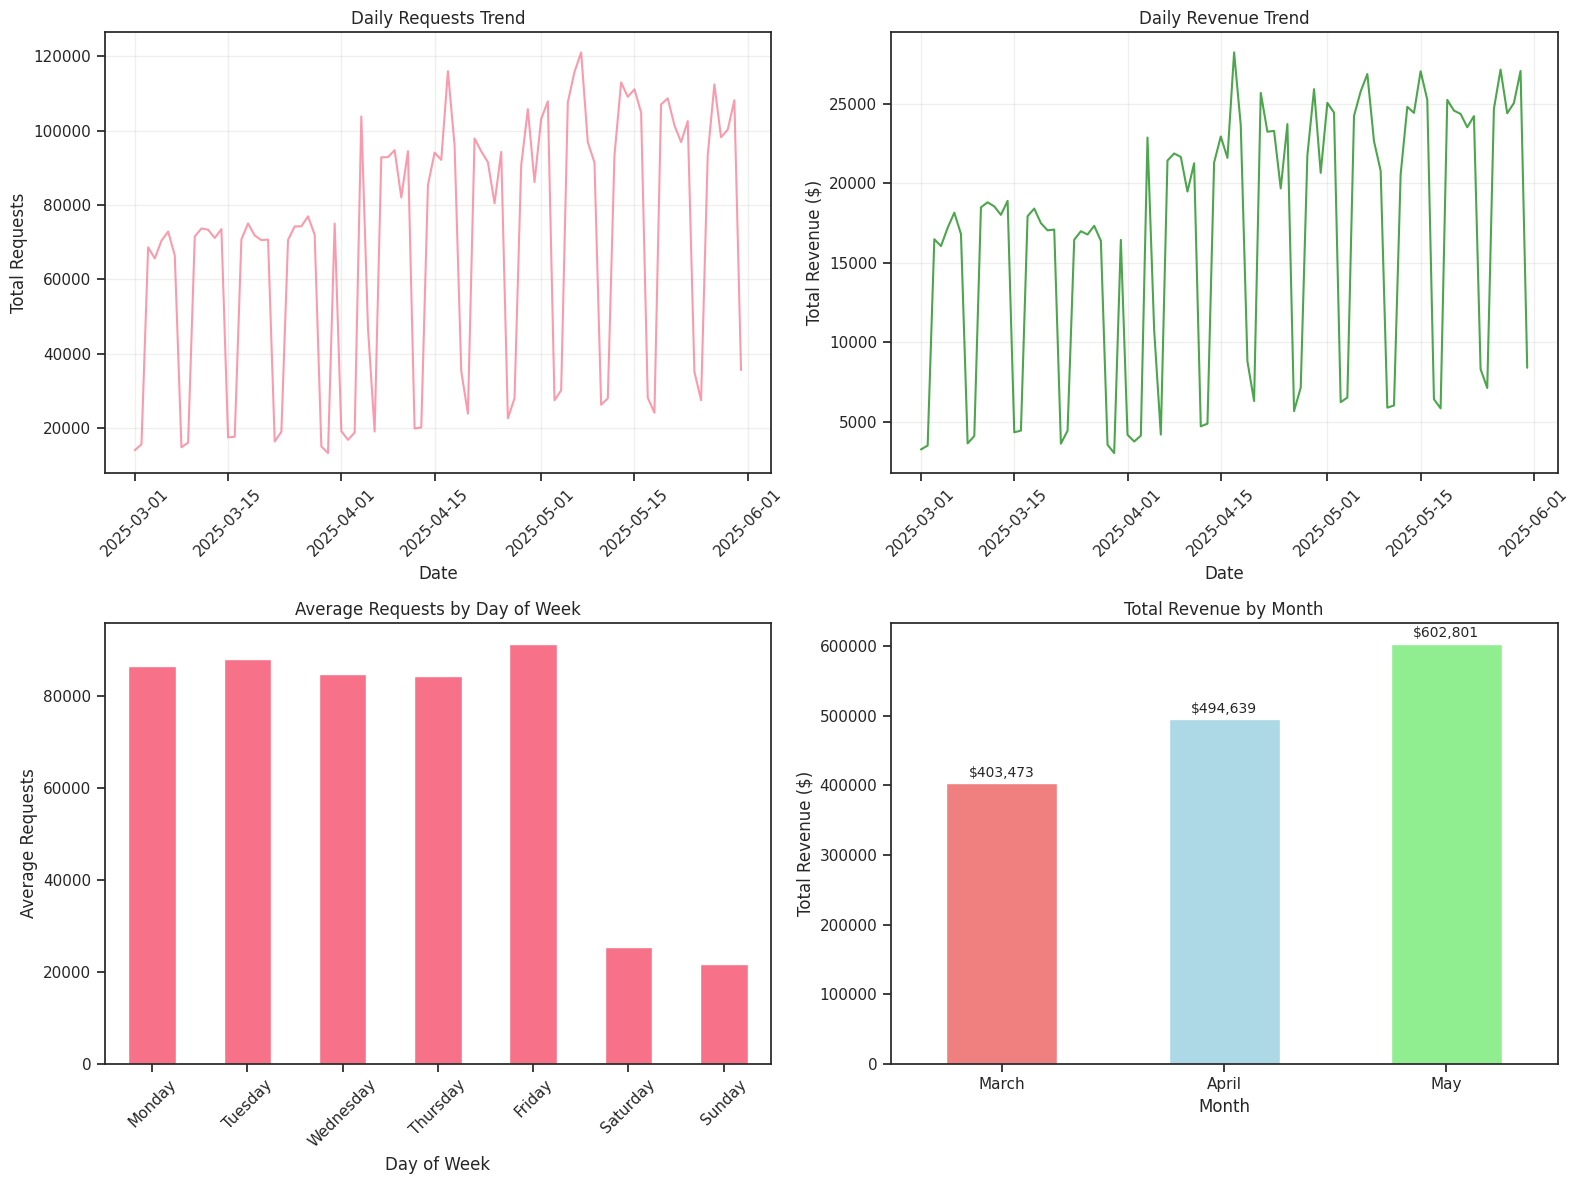

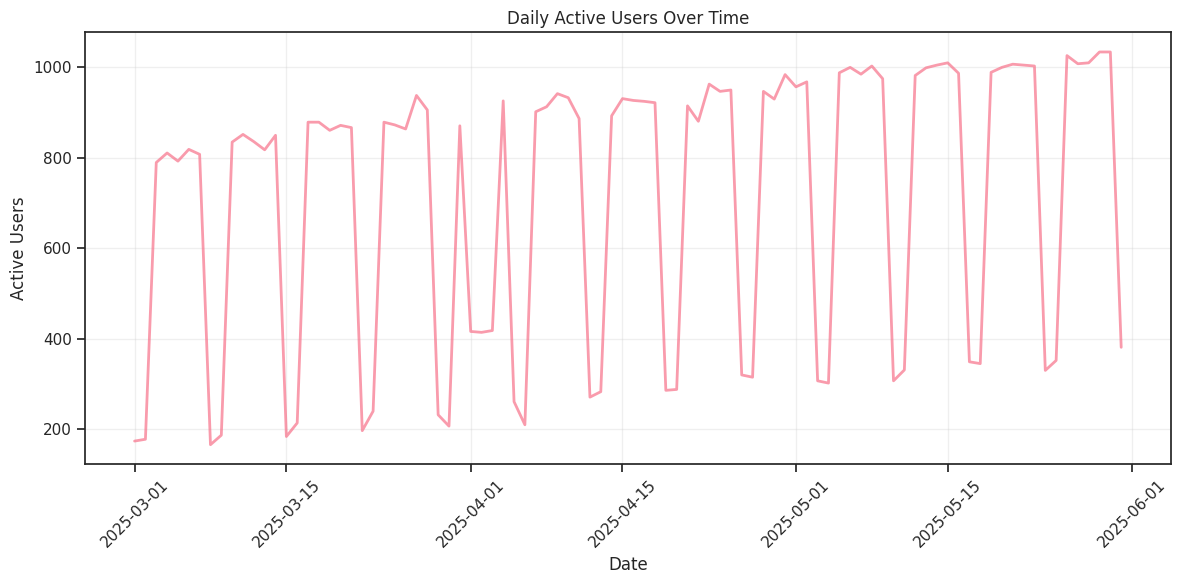

In [35]:
# Temporal trends visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Daily trends over time
ax1 = axes[0, 0]
ax1.plot(daily_trends['date'], daily_trends['total_requests'], label='Requests', alpha=0.7)
ax1.set_title('Daily Requests Trend')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Requests')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Daily revenue trends
ax2 = axes[0, 1]
ax2.plot(daily_trends['date'], daily_trends['total_revenue'], label='Revenue', color='green', alpha=0.7)
ax2.set_title('Daily Revenue Trend')
ax2.set_xlabel('Date')
ax2.set_ylabel('Total Revenue ($)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Day of week patterns
ax3 = axes[1, 0]
dow_analysis['total_requests'].plot(kind='bar', ax=ax3)
ax3.set_title('Average Requests by Day of Week')
ax3.set_xlabel('Day of Week')
ax3.set_ylabel('Average Requests')
ax3.tick_params(axis='x', rotation=45)

# Monthly comparison
ax4 = axes[1, 1]
monthly_trends['total_revenue'].plot(kind='bar', ax=ax4, color=['lightcoral', 'lightblue', 'lightgreen'])
ax4.set_title('Total Revenue by Month')
ax4.set_xlabel('Month')
ax4.set_ylabel('Total Revenue ($)')
ax4.tick_params(axis='x', rotation=0)

# Add values on top of bars
for i, v in enumerate(monthly_trends['total_revenue']):
    ax4.text(i, v + v*0.01, f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Additional insights: Active users over time
plt.figure(figsize=(12, 6))
plt.plot(daily_trends['date'], daily_trends['active_users'], alpha=0.7, linewidth=2)
plt.title('Daily Active Users Over Time')
plt.xlabel('Date')
plt.ylabel('Active Users')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

Analysis of the aggregated time-series charts reveals two key patterns:

1.  **Steady Growth:** There is clear, stable month-over-month growth in revenue, requests, and active users.
2.  **"Weekday/Weekend" Cycle:** There is a sharp, repeating cycle of high activity from Monday to Friday, followed by a significant drop in activity every Saturday and Sunday.
3.  **Specific Dips:** Within this main cycle, we also see specific events, such as a noticeable drop in activity around the 14th week of the year (early April).

This "Weekday/Weekend" pattern suggests a hypothesis that our user base consists of different segments (e.g., corporate B2B clients and individual "Prosumer" users). To test this, we must segment the activity by license type.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">


### 7.3. Proof: Two Different Markets

--- Starting 7.2: Weekday vs. Weekend Analysis ---
Analysis: Weekday vs Weekend Activity by License Type
Analysis    Weekday  Weekend  Concentration_Ratio (Wd/We)
license                                                  
Enterprise  27051.4   6186.5                         4.37
Premium     24292.3   5208.5                         4.66
Standard    21152.8   7185.1                         2.94
Basic       14498.5   5026.8                         2.88
--- Plotting 7.2: Combined Weekday/Weekend Analysis ---


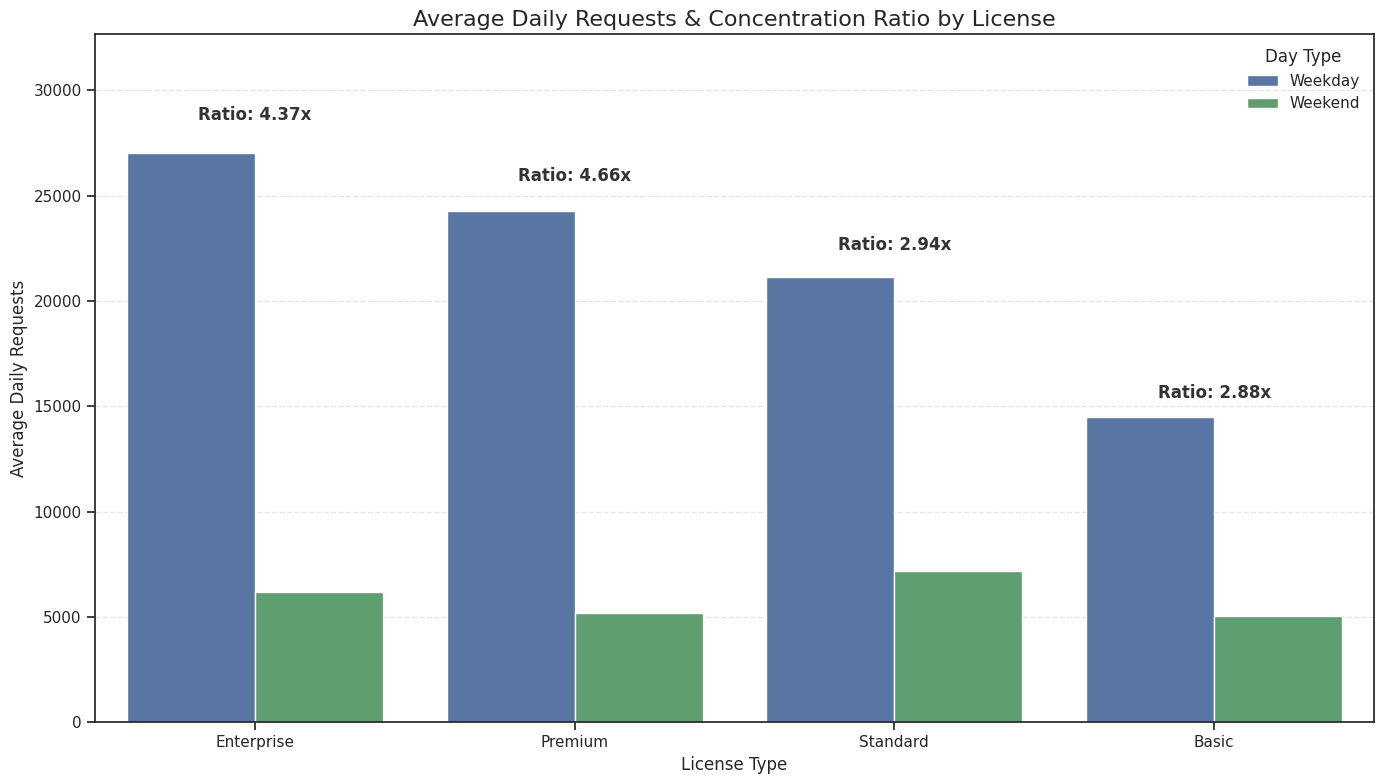

In [ ]:
print("--- Starting 7.2: Weekday vs. Weekend Analysis ---")

# 1. First, get the TOTAL daily requests per license
daily_license_requests = df.groupby(['day_id', 'license', 'day_of_week'])['requests_cnt'].sum().reset_index()

# 2. Define day types
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
daily_license_requests['day_type'] = daily_license_requests['day_of_week'].apply(
    lambda x: 'Weekday' if x in weekdays else 'Weekend'
)

# 3. Calculate the AVERAGE daily requests for each group
avg_daily_activity = daily_license_requests.groupby(['license', 'day_type'])['requests_cnt'].mean().reset_index()

# 4. Pivot the data to create the comparison table
activity_pivot = avg_daily_activity.pivot_table(
    index='license',
    columns='day_type',
    values='requests_cnt'
).round(1)

# 5. Calculate the Concentration Ratio
activity_pivot['Concentration_Ratio (Wd/We)'] = (activity_pivot['Weekday'] / activity_pivot['Weekend']).round(2)

# 6. Clean up for presentation
activity_pivot.columns.name = 'Analysis'
activity_pivot = activity_pivot[['Weekday', 'Weekend', 'Concentration_Ratio (Wd/We)']]
activity_pivot = activity_pivot.reindex(['Enterprise', 'Premium', 'Standard', 'Basic'])

print("Analysis: Weekday vs Weekend Activity by License Type")
# This will print the DataFrame directly without needing 'tabulate'
print(activity_pivot)

print("--- Plotting 7.2: Combined Weekday/Weekend Analysis ---")

plot_df = activity_pivot.reset_index().melt(
    id_vars='license',
    value_vars=['Weekday', 'Weekend'],
    var_name='Day Type',
    value_name='Average Daily Requests'
)

license_order = ['Enterprise', 'Premium', 'Standard', 'Basic']
plot_df = plot_df[plot_df['license'].isin(license_order)]

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=plot_df,
    x='license',
    y='Average Daily Requests',
    hue='Day Type',
    palette={'Weekday': '#4C72B0', 'Weekend': '#55A868'},
    order=license_order
)

plt.title('Average Daily Requests & Concentration Ratio by License', fontsize=16)
plt.ylabel('Average Daily Requests', fontsize=12)
plt.xlabel('License Type', fontsize=12)
plt.legend(title='Day Type', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

current_y_limit = ax.get_ylim()[1]
ax.set_ylim(top=current_y_limit * 1.15) 

max_heights = plot_df.groupby('license')['Average Daily Requests'].max().reindex(license_order)
ratios = activity_pivot['Concentration_Ratio (Wd/We)'].reindex(license_order)

x_coords_map = {label.get_text(): i for i, label in enumerate(ax.get_xticklabels())}

for license_name in license_order:
    if license_name not in x_coords_map:
        continue
        
    x_pos = x_coords_map[license_name]
    height = max_heights.loc[license_name]
    ratio = ratios.loc[license_name]

    if pd.notna(height) and pd.notna(ratio):
        ax.text(
            x_pos,
            height * 1.05,
            f"Ratio: {ratio:.2f}x", 
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold',
            color='#333333'
        )

plt.tight_layout()
plt.show()

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 7.3. Insight: Two Different Markets

The chart above ("Average Daily Requests & Concentration Ratio") provides the definitive proof. It segments the "Weekday/Weekend" pattern by license type and confirms our hypothesis.

**Insight: Two Different Markets Confirmed**

The data clearly divides our user base into two markets with different behaviors:

1.  **The B2B Segment (Enterprise & Premium):**
    This group shows an **extreme concentration ratio** (Enterprise: **4.37x**, Premium: **4.66x**). Their work is intensely focused on weekdays. This proves the product is deeply integrated into corporate workflows and sprint cycles.

2.  **The Prosumer Segment (Basic & Standard):**
    This group shows a **much lower concentration ratio** (Standard: **2.94x**, Basic: **2.88x**). While they are still more active on weekdays, their drop-off is far less severe. This signals a different, more individual-driven use case (freelancers, hobby projects) that also occurs on personal time.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 7.4. Analysis of Temporal Trends

--- 7.4.1. Monthly Trend Summary ---

--- Monthly Spend & Share: LICENSE ---


license,Spend_Basic,Spend_Enterprise,Spend_Premium,Spend_Standard,Share_Basic,Share_Enterprise,Share_Premium,Share_Standard
month_name,,,,,,,,
March,70054.60,145040.03,96724.34,91654.21,0.173629,0.359479,0.239729,0.227163
April,84432.45,149673.57,135529.54,125003.26,0.170695,0.302592,0.273997,0.252716
May,101766.81,178524.17,171717.62,150792.74,0.168823,0.296158,0.284866,0.250153



--- Monthly Spend & Share: MODEL ---


model,Spend_Model_A,Spend_Model_B,Spend_Model_C,Spend_Model_D,Spend_Model_E,Share_Model_A,Share_Model_B,Share_Model_C,Share_Model_D,Share_Model_E
month_name,,,,,,,,,,
March,89295.04,70830.99,92491.17,104891.45,45964.53,0.221316,0.175553,0.229237,0.259971,0.113922
April,123642.10,87053.16,120114.33,119906.01,43923.22,0.249964,0.175993,0.242832,0.242411,0.088799
May,152139.94,110281.93,154016.24,136809.77,49553.46,0.252388,0.182949,0.255501,0.226957,0.082205



--- Monthly Spend & Share: FEATURE ---


feature,Spend_Feature_1,Spend_Feature_2,Spend_Feature_3,Spend_Feature_4,Spend_Feature_5,Share_Feature_1,Share_Feature_2,Share_Feature_3,Share_Feature_4,Share_Feature_5
month_name,,,,,,,,,,
March,168997.79,115137.26,78455.05,22741.59,18141.49,0.418858,0.285365,0.194449,0.056365,0.044963
April,200414.70,146488.79,93882.53,30715.41,23137.39,0.405174,0.296153,0.189800,0.062097,0.046776
May,241096.67,171217.46,119626.93,41895.19,28965.09,0.399960,0.284036,0.198452,0.069501,0.048051



--- 7.4.2 Plotting 3x2 Weekly Trend Canvas (All Line Plots) ---


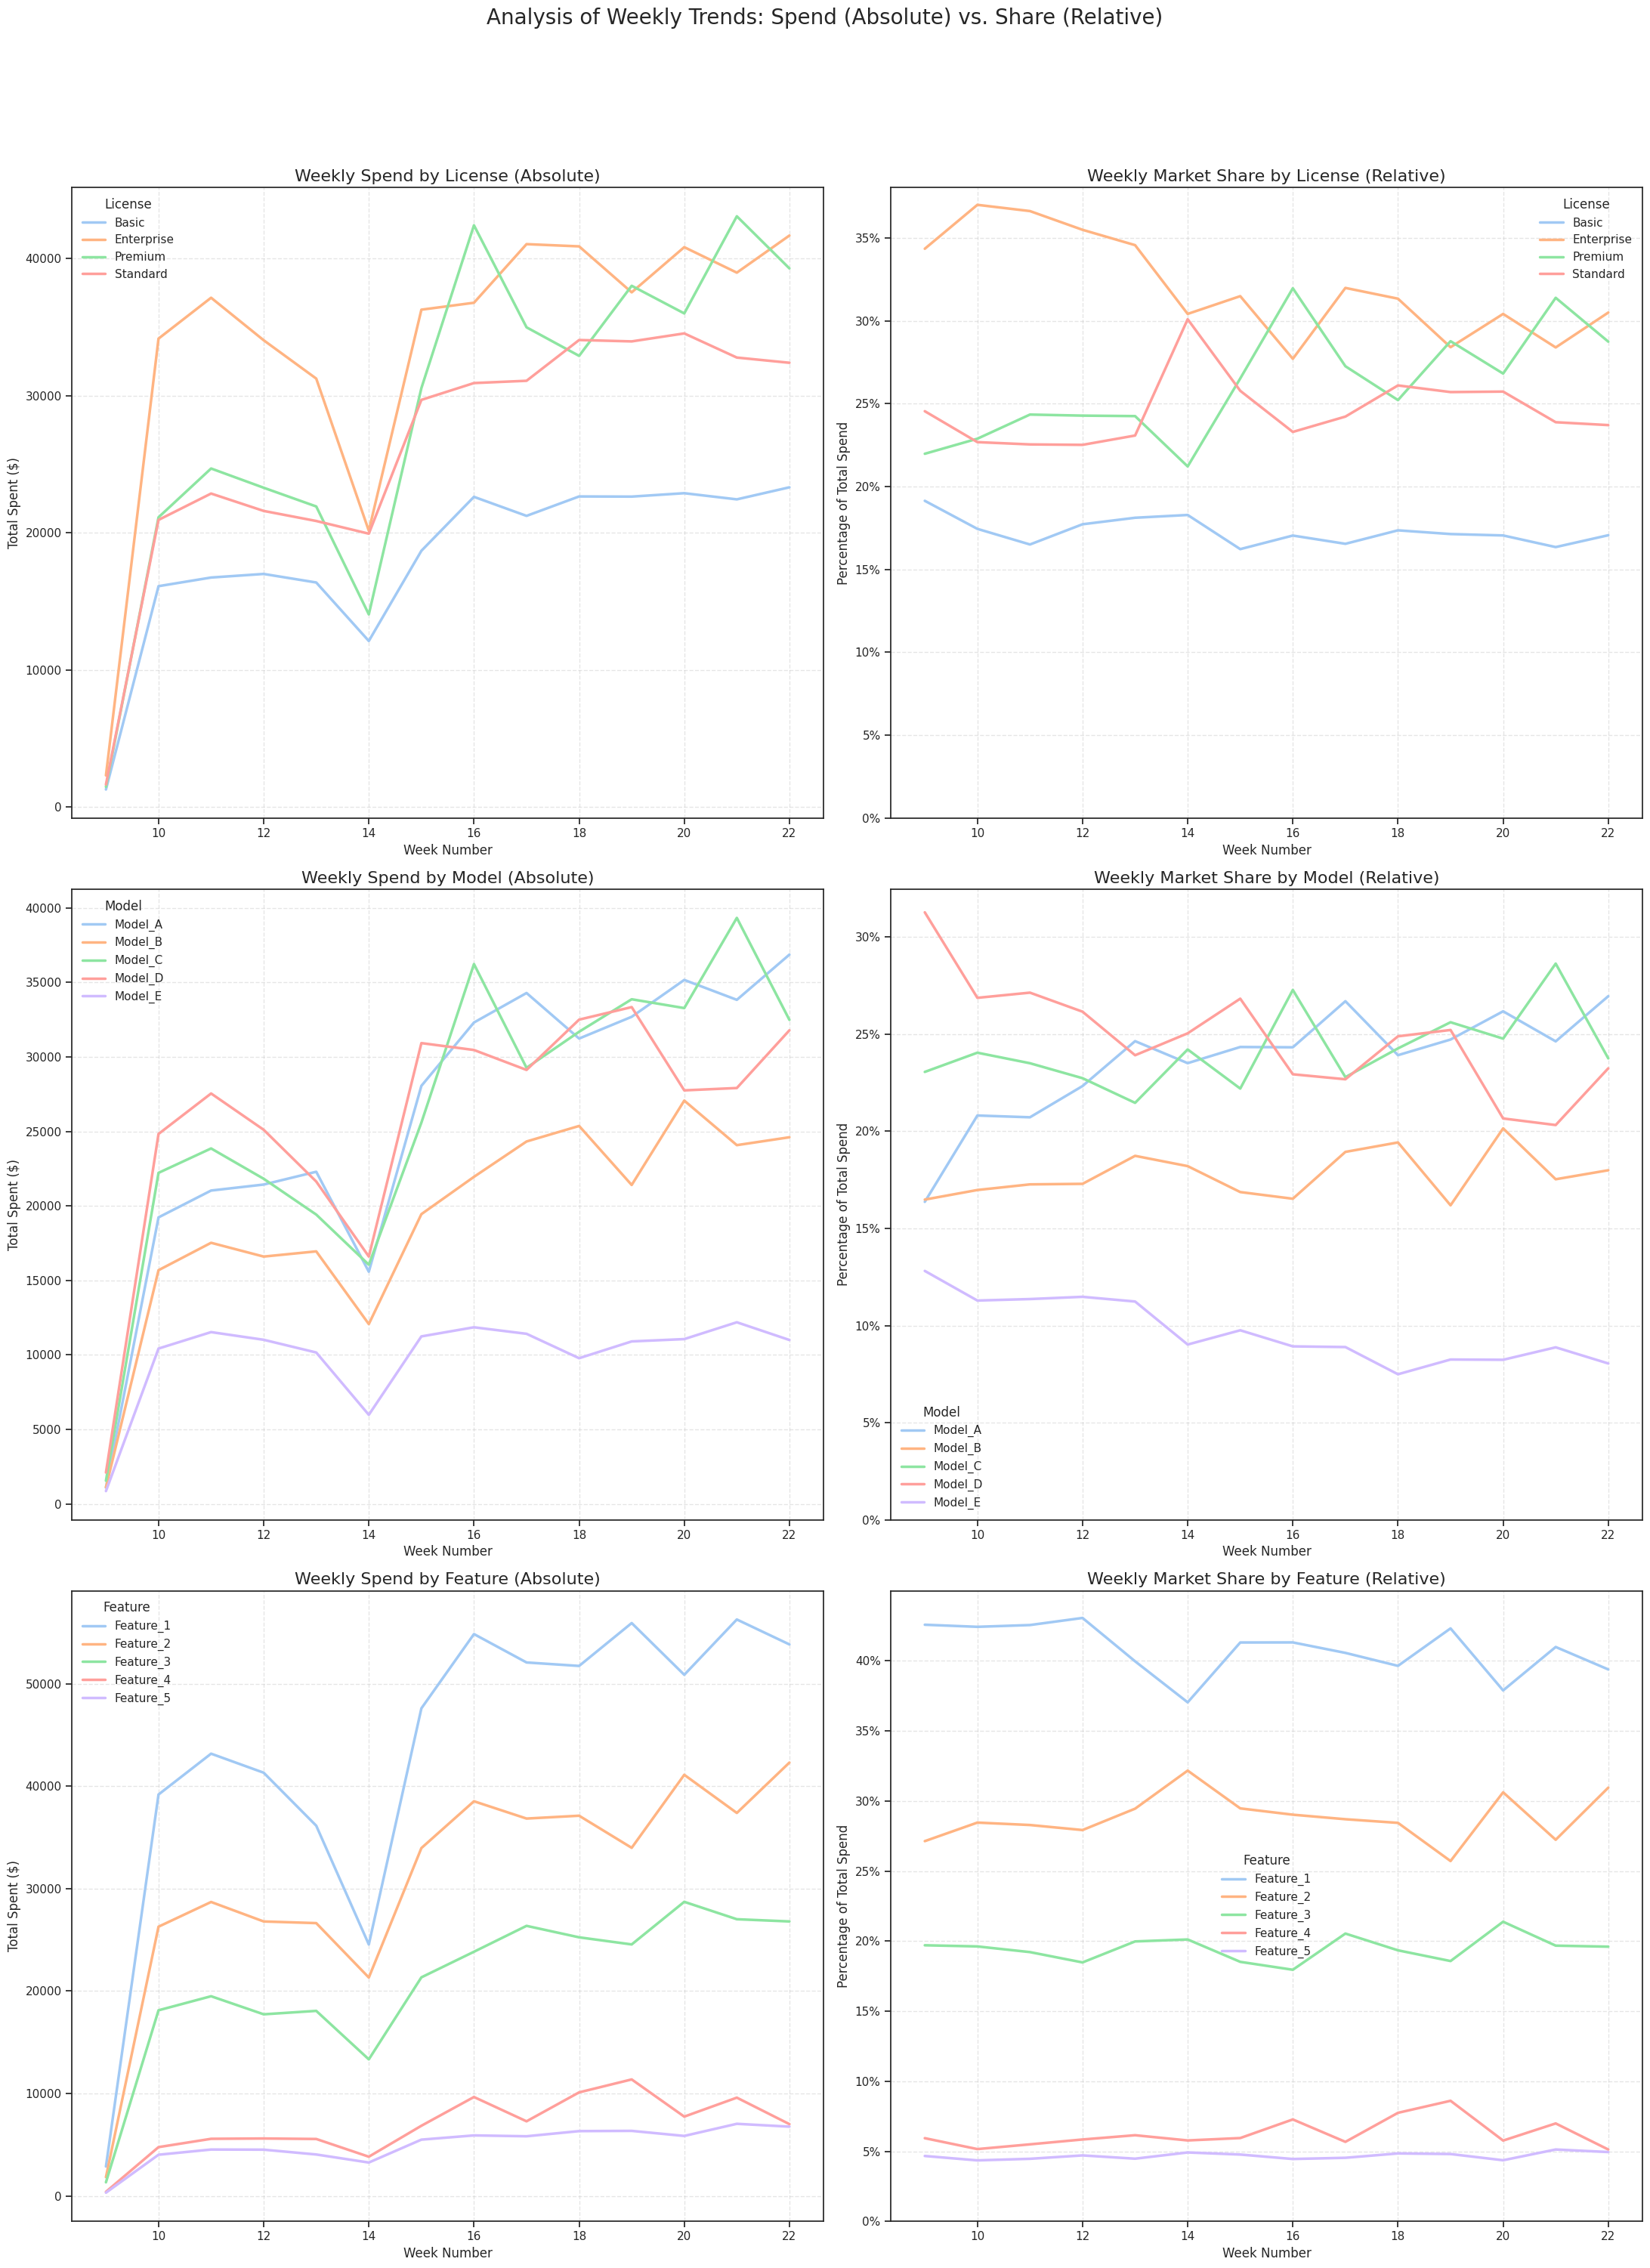

In [ ]:
print("--- 7.4.1. Monthly Trend Summary ---")

month_order = ['March', 'April', 'May']
monthly_total_spent = df.groupby('month_name')['spent_amount'].sum().reindex(month_order)

monthly_license = df.groupby(['month_name', 'license'])['spent_amount'].sum().unstack().reindex(month_order)
monthly_license_share = monthly_license.divide(monthly_total_spent, axis=0).fillna(0)
print("\n--- Monthly Spend & Share: LICENSE ---")
display(pd.concat([
    monthly_license.add_prefix('Spend_'),
    monthly_license_share.add_prefix('Share_')
], axis=1))

monthly_model = df.groupby(['month_name', 'model'])['spent_amount'].sum().unstack().reindex(month_order)
monthly_model_share = monthly_model.divide(monthly_total_spent, axis=0).fillna(0)
print("\n--- Monthly Spend & Share: MODEL ---")
display(pd.concat([
    monthly_model.add_prefix('Spend_'),
    monthly_model_share.add_prefix('Share_')
], axis=1))

monthly_feature = df.groupby(['month_name', 'feature'])['spent_amount'].sum().unstack().reindex(month_order)
monthly_feature_share = monthly_feature.divide(monthly_total_spent, axis=0).fillna(0)
print("\n--- Monthly Spend & Share: FEATURE ---")
display(pd.concat([
    monthly_feature.add_prefix('Spend_'),
    monthly_feature_share.add_prefix('Share_')
], axis=1))


print("\n--- 7.4.2 Plotting 3x2 Weekly Trend Canvas (All Line Plots) ---")

weekly_total_spent = df.groupby('week_number')['spent_amount'].sum()

weekly_license_spend = df.groupby(['week_number', 'license'])['spent_amount'].sum().unstack().fillna(0)
weekly_license_share = weekly_license_spend.divide(weekly_total_spent, axis=0).fillna(0)
license_list = weekly_license_spend.columns.tolist()

weekly_model_spend = df.groupby(['week_number', 'model'])['spent_amount'].sum().unstack().fillna(0)
weekly_model_share = weekly_model_spend.divide(weekly_total_spent, axis=0).fillna(0)
model_list = weekly_model_spend.columns.tolist()

weekly_feature_spend = df.groupby(['week_number', 'feature'])['spent_amount'].sum().unstack().fillna(0)
weekly_feature_share = weekly_feature_spend.divide(weekly_total_spent, axis=0).fillna(0)
feature_list = weekly_feature_spend.columns.tolist()


fig, axes = plt.subplots(3, 2, figsize=(22, 30))
fig.suptitle('Analysis of Weekly Trends: Spend (Absolute) vs. Share (Relative)', fontsize=20, y=1.03)
week_index = weekly_total_spent.index

ax = axes[0, 0]
for lic in license_list:
    sns.lineplot(x=week_index, y=weekly_license_spend[lic], ax=ax, label=lic, linewidth=2.5)
ax.set_title('Weekly Spend by License (Absolute)', fontsize=16)
ax.set_ylabel('Total Spent ($)', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='License')
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[0, 1]
for lic in license_list:
    sns.lineplot(x=week_index, y=weekly_license_share[lic], ax=ax, label=lic, linewidth=2.5)
ax.set_title('Weekly Market Share by License (Relative)', fontsize=16)
ax.set_ylabel('Percentage of Total Spend', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='License')
ax.set_ylim(0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[1, 0]
for mod in model_list:
    sns.lineplot(x=week_index, y=weekly_model_spend[mod], ax=ax, label=mod, linewidth=2.5)
ax.set_title('Weekly Spend by Model (Absolute)', fontsize=16)
ax.set_ylabel('Total Spent ($)', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='Model')
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[1, 1]
for mod in model_list:
    sns.lineplot(x=week_index, y=weekly_model_share[mod], ax=ax, label=mod, linewidth=2.5)
ax.set_title('Weekly Market Share by Model (Relative)', fontsize=16)
ax.set_ylabel('Percentage of Total Spend', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='Model')
ax.set_ylim(0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[2, 0]
for feat in feature_list:
    sns.lineplot(x=week_index, y=weekly_feature_spend[feat], ax=ax, label=feat, linewidth=2.5)
ax.set_title('Weekly Spend by Feature (Absolute)', fontsize=16)
ax.set_ylabel('Total Spent ($)', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='Feature')
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[2, 1]
for feat in feature_list:
    sns.lineplot(x=week_index, y=weekly_feature_share[feat], ax=ax, label=feat, linewidth=2.5)
ax.set_title('Weekly Market Share by Feature (Relative)', fontsize=16)
ax.set_ylabel('Percentage of Total Spend', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='Feature')
ax.set_ylim(0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

### 7.4. Analysis of Temporal Trends

The monthly summary tables and the 3x2 weekly trend charts (image image_86ba34.jpg) provide a clear picture of portfolio performance over time. The key insight is stability: our product mix is mature, and user preferences are consistent.

A notable dip is visible across all weekly charts around week 14, which corresponds to the drop in users we noted in section 7.2.

**Insight 1: License Share is Stable, but Enterprise is Winning the Growth Battle**

*   **Monthly Data (Tables):** The share of revenue from each license is remarkably stable. Enterprise holds ~30-36%, Premium ~24-28%, Standard ~23-25%, and Basic ~17%.

*   **Weekly Data (Charts):** The line charts confirm this.
    *   **Absolute Spend (Top-Left):** All four license types are growing in absolute spend, showing a healthy "rising tide."
    *   **Relative Share (Top-Right):** The "Market Share" lines are almost perfectly flat. This shows there is no significant churn or migration between license tiers on a weekly basis. The one exception is Enterprise (blue line), which shows a slight but steady upward trend in market share, pulling ahead of Premium (green line) as the period progresses.

**Insight 2: The "Two Economies" (A/C/D) are Growing in Lockstep**

*   **Monthly Data (Tables):** Our "two economies" (Premium-Cost A/B and Economy-Cost C/D/E) are growing proportionally. Model A (Premium) grew from 22.1% to 25.2% share. Model C (Economy) grew from 22.9% to 25.6% share. Their growth is balanced.

*   **Weekly Data (Charts):**
    *   **Absolute Spend (Mid-Left):** The top 3 revenue drivers (A, C, D) are all growing together.
    *   **Relative Share (Mid-Right):** The market share lines for models are also extremely stable, confirming that users are not migrating between model tiers.

**Insight 3: Feature Preference is Fixed, confirming "Features are Commodities"**

*   **Monthly Data (Tables):** The revenue share for all five features is the most stable metric in the entire dataset. Feature_1 consistently holds ~40-42% of the revenue, and Feature_2 holds ~28-29%.

*   **Weekly Data (Charts):**
    *   **Absolute Spend (Bottom-Left):** All features are growing in absolute spend.
    *   **Relative Share (Bottom-Right):** The lines are perfectly flat. This is the strongest proof that features are stable "tools" and that user preference does not change over time. Feature_1 is the clear market leader, and Feature_4/Feature_5 are consistently niche.

**Overall Conclusion:** The business is not in a state of high flux. It is a stable, mature system showing consistent, healthy growth across all product segments. The "Maximalist" (Enterprise/Model A) and "Optimist" (Premium/Model C/D) strategies are both growing in parallel, proving the long-term health of our two-pillar business model.

<hr style="border: 1px solid #CB4C4E; margin: 20px 0px;">

## 8. Conclusion: Strategic Insights & Recommendations

This analysis has uncovered a complex and multifaceted product usage ecosystem. The key takeaway is that our user base is not monolithic; it is composed of distinct segments, each driven by its own logic and strategy. Understanding these differences is the key to future growth.

### 8.1. Key Insights & Their Business Implications

**Insight 1: The Model as the "Engine" — The Fundamental Driver of Cost**

*   **What it means:** The fundamental factor that defines cost and value for the user is the choice of the underlying "engine"—a **model** from the "Economy Tier" (C, D, E) with an average request cost of ~$0.19, or the "Premium Tier" (A, B) with a cost of ~$0.37. This decision shapes the entire economics of product usage. Features, in turn, act as tools to operate this engine. However, within this system, strong and effective pairings exist that stand out from the general distribution. For example, the anomalously high popularity of the **Model_D + Feature_2** combination points to a very specific and in-demand use case.
*   **Business Implications:** Our core value proposition is access to different tiers of computational power ("engines"), not just a collection of features. Marketing and product strategy must be built around this idea. At the same time, understanding and promoting the most successful "combos" (like MD+F2) allows us to sell not just a tool, but proven "recipes" for solving specific user problems.

**Insight 2: The Hybrid Revenue Model — Stability Through Two Pillars**

*   **What it means:** The business is resilient and not dependent on a small group of "whales." Revenue is balanced between:
    1.  **The "Concentrated Core" (Top 20% of users):** These are clients with **Enterprise** and **Premium** licenses, who generate **55.6%** of the revenue.
    2.  **The "High-Value Long Tail" (Bottom 80% of users):** These are clients with **Basic** and **Standard** licenses, who provide a critical **44.4%** of the revenue.
*   **Business Implications:** This confirms the success of a dual strategy: **Sales-Led** for growth within the "core" and **Product-Led Growth** for scaling the "long tail." Weakening either pillar would directly impact revenue.

**Insight 3: Two Distinct High-Value Customer Personas**

*   **What it means:** Our most valuable customers (Enterprise and Premium) are two different groups with fundamentally different approaches to spending:
    *   **Enterprise — "The Strategic Investors":** They are willing to allocate a **significantly larger share (46.9%)** of their budget to expensive Premium models when the task demands it. They pay for results in critical scenarios.
    *   **Premium — "The Pragmatic Optimizers":** They are much more cost-conscious, adhering strictly to budget-friendly models and spending **noticeably less (39.6%)** on expensive alternatives. They pay for efficiency and volume.
*   **Business Implications:** We need to sell to these two segments in completely different ways. Enterprise seeks "power on demand," while Premium seeks "maximum output per dollar."

**Insight 4: Two Different Markets — B2B and "Prosumers"**

*   **What it means:** Weekly activity patterns prove that **Enterprise & Premium** constitute a B2B market, deeply integrated into professional workflows. **Basic & Standard** represent a "prosumer" market (freelancers, indie developers), for whom the product is both a work tool and part of personal projects.
*   **Business Implications:** These are not rungs on a single ladder but parallel worlds. The growth strategy should focus on acquiring customers directly into their relevant market, rather than aiming for mass "conversion" from one to the other.

**Hypothesis 5: "Niche" Features as Indicators of Growth Readiness**

*   **What it means:** Feature_4 and Feature_5 have nearly 100% adoption among Enterprise/Premium users but are used significantly less on basic tiers.
*   **Business Implications (Hypothesis):** This is a strong signal that these features could be **Product-Qualified Lead (PQL)** indicators. A user on a basic plan who starts using them has likely "outgrown" their tier and is ready for an upsell. This hypothesis requires analytical validation.



### 8.2. Strategic Recommendations

1.  **Develop Segmented Value Propositions:**
    *   **Marketing to "Investors" (Enterprise):** Create case studies that showcase solving complex, mission-critical tasks using **Premium models (A, B)**. Position them as an investment in quality and performance that pays off on difficult projects.
    *   **Marketing to "Optimizers" (Premium):** Focus communications on the maximum efficiency and volume of work achieved with **Economy models (C, D, E)**. Show how a Premium license allows them to do more for less.
    *   **Promote "Champion Combos":** Actively market the most profitable combinations (Model_C+Feature_1, Model_D+Feature_2) as "proven recipes for success" for specific tasks.

2.  **Strengthen Dual Acquisition Funnels:**
    *   **For B2B (Enterprise/Premium):** Reinforce channels and messaging targeted at corporate clients, using data on workflow integration (weekday activity) as a key selling point.
    *   **For "Prosumers" (Basic/Standard):** Continue developing the Product-Led Growth funnel, emphasizing accessibility, flexibility, and support for individual projects.

3.  **Optimize the Product Strategy:**
    *   **Develop the "Engines":** Focus R&D on improving and clearly differentiating the capabilities of Premium and Economy models. The difference in their performance and use cases should be obvious.
    *   **Investigate "Anomalies":** Task the product team with understanding why the Model_D+Feature_2 combo is so popular and whether this success can be replicated or scaled.


### 8.3. Directions for Further Analysis

This analysis has uncovered several layers, but beneath each lies another that requires deeper investigation. This work focused on high-level strategic conclusions, but further research is needed to refine them:

1.  **Deconstruct the "Model-Feature" Synergy:**
    *   **What I missed:** I identified top combinations but didn't analyze their dynamics over time or at the session level.
    *   **What needs to be done:** Conduct a deep-dive analysis of sessions where the leading combos (MC+F1, MD+F1, MD+F2) are used. What is the length of these sessions? What other features are used alongside them? This will help understand the *context* and *scenario* behind the numbers, turning correlation into causation.

2.  **Statistically Validate the "Gateway Feature" (PQL) Hypothesis:**
    *   **What I missed:** I proposed the hypothesis based on differing adoption rates but did not test it statistically.
    *   **What needs to be done:** Conduct a cohort analysis. Compare the conversion rate to paid/higher tiers between two groups of Basic/Standard users: those who used F4/F5 and those who did not. This will provide a definitive answer as to whether these features are predictors of growth.

3.  **Build Retention and LTV Models:**
    *   **What I missed:** The analysis focused on a 3-month snapshot, without examining long-term dynamics.
    *   **What needs to be done:** Build retention curves for each of the four license types. Calculate the LTV for an average user in each segment. This will reveal which market not only generates revenue now but is also the most valuable in the long run.

4.  **Conduct Qualitative Research to Understand the "Why":**
    *   **What I missed:** The entire analysis was quantitative ("what is happening").
    *   **What needs to be done:** Conduct a series of in-depth interviews with users from the Enterprise and Premium segments. This is essential to understand their motivation: what specific business problems drive their model choices? How do they define "quality"? What does "efficiency" mean to them? This is the only way to truly understand their behavioral strategies.